In [ ]:
%load_ext sql

import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv(encoding='utf-8-sig')

mysql_host = os.getenv("MYSQL_HOST")
mysql_user = os.getenv("MYSQL_USER")
mysql_password = os.getenv("MYSQL_PASSWORD")
mysql_database = os.getenv("MYSQL_DATABASE")

connection_string = f"mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}/{mysql_database}"

# 🔥 Force SQL magic to use THIS connection string — prevents the error
%sql $connection_string

print("✅ MySQL Connected Successfully!")


# START OF PART 3 - Weaving the data threads of Maji Ndogo's narrative

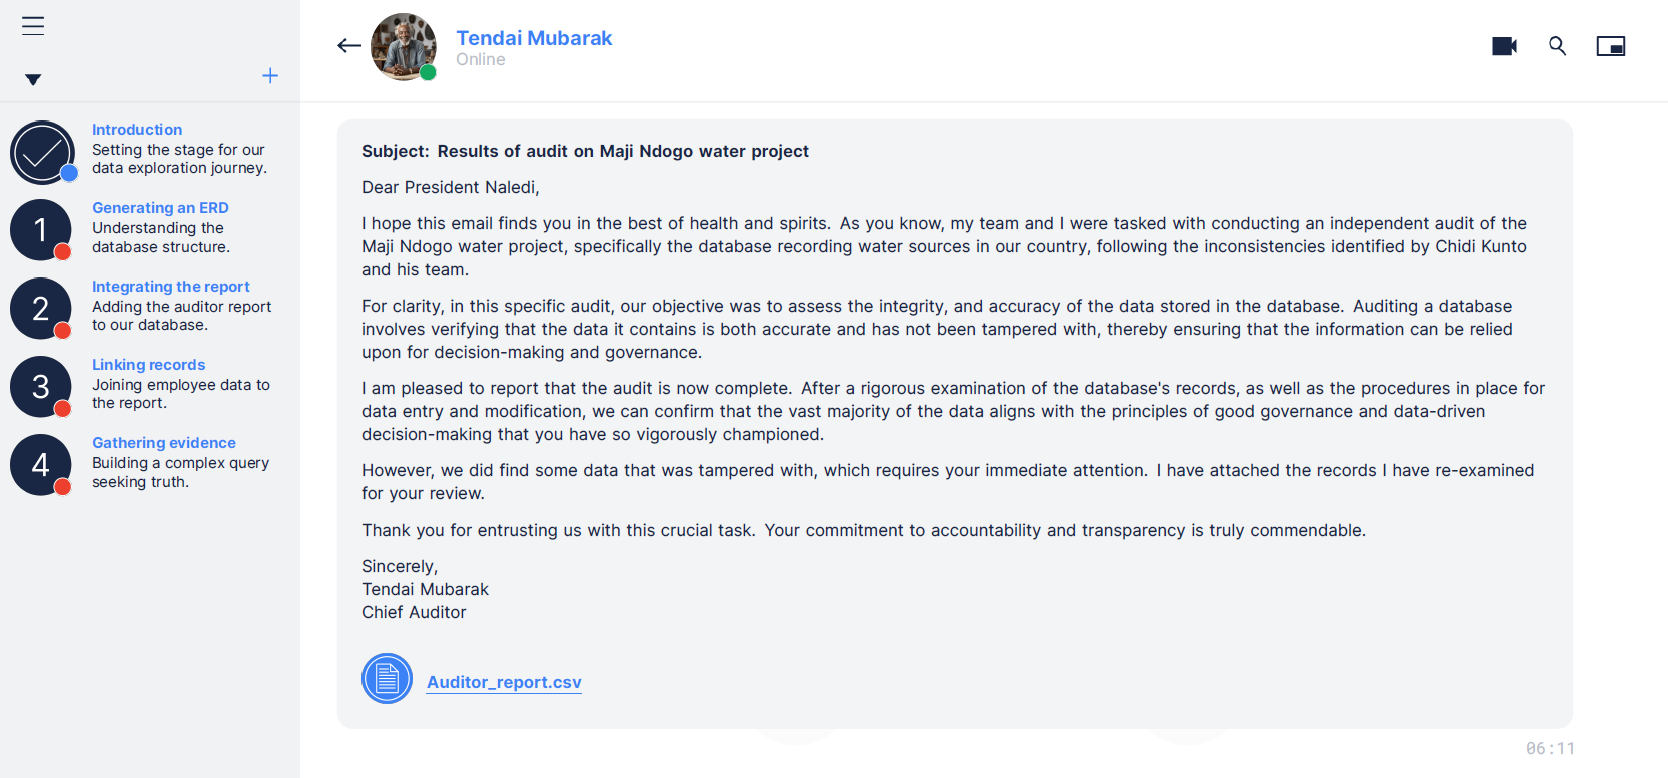

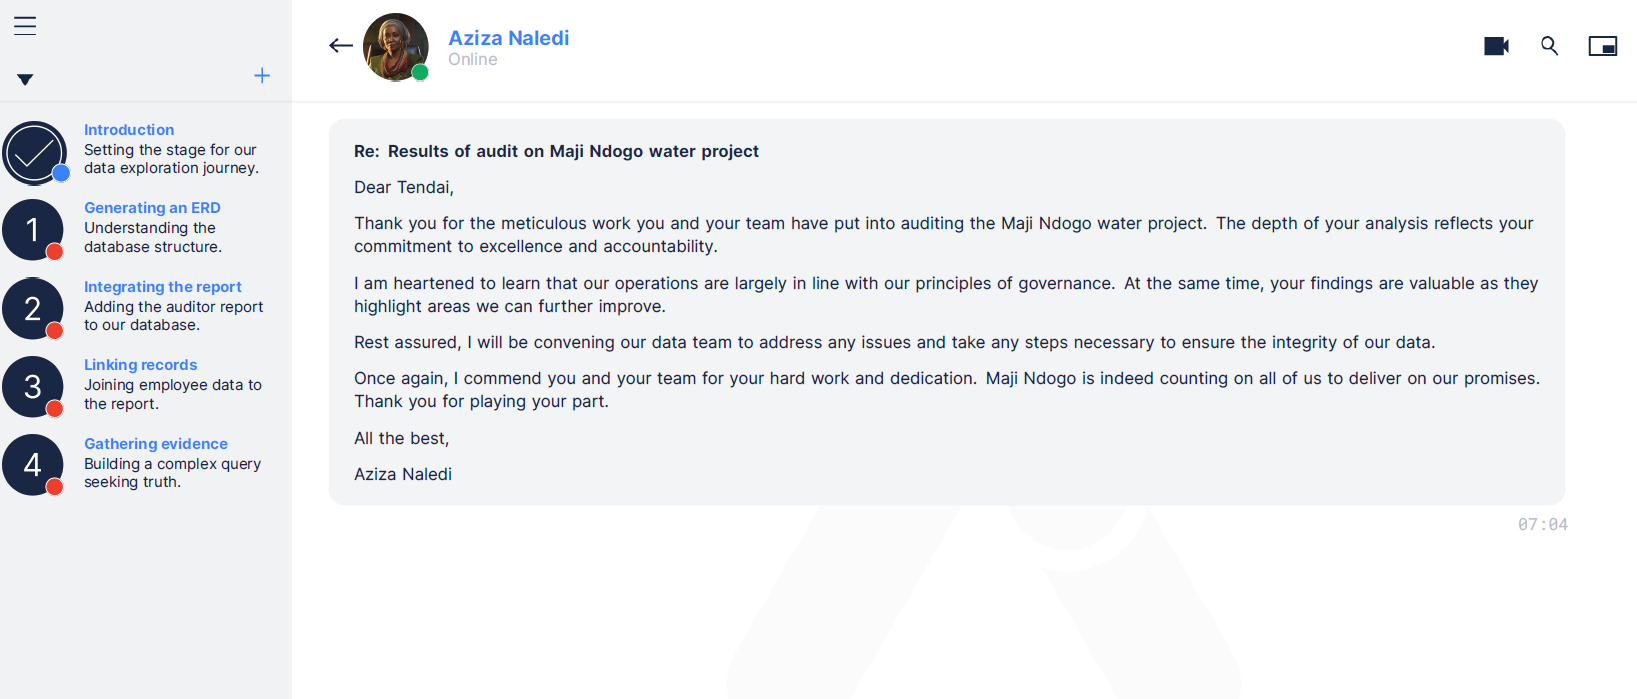

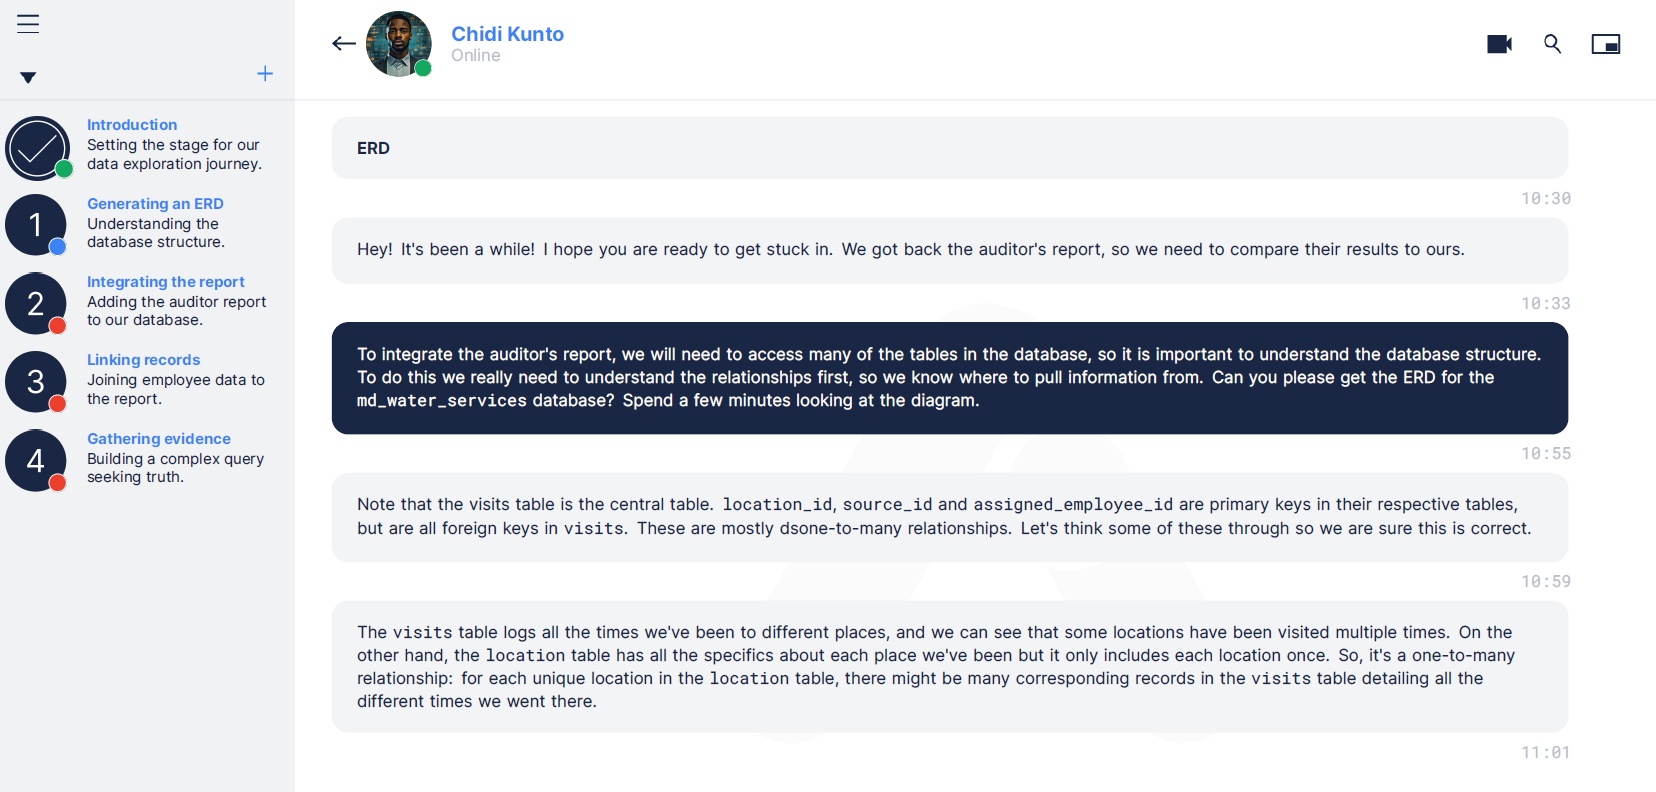

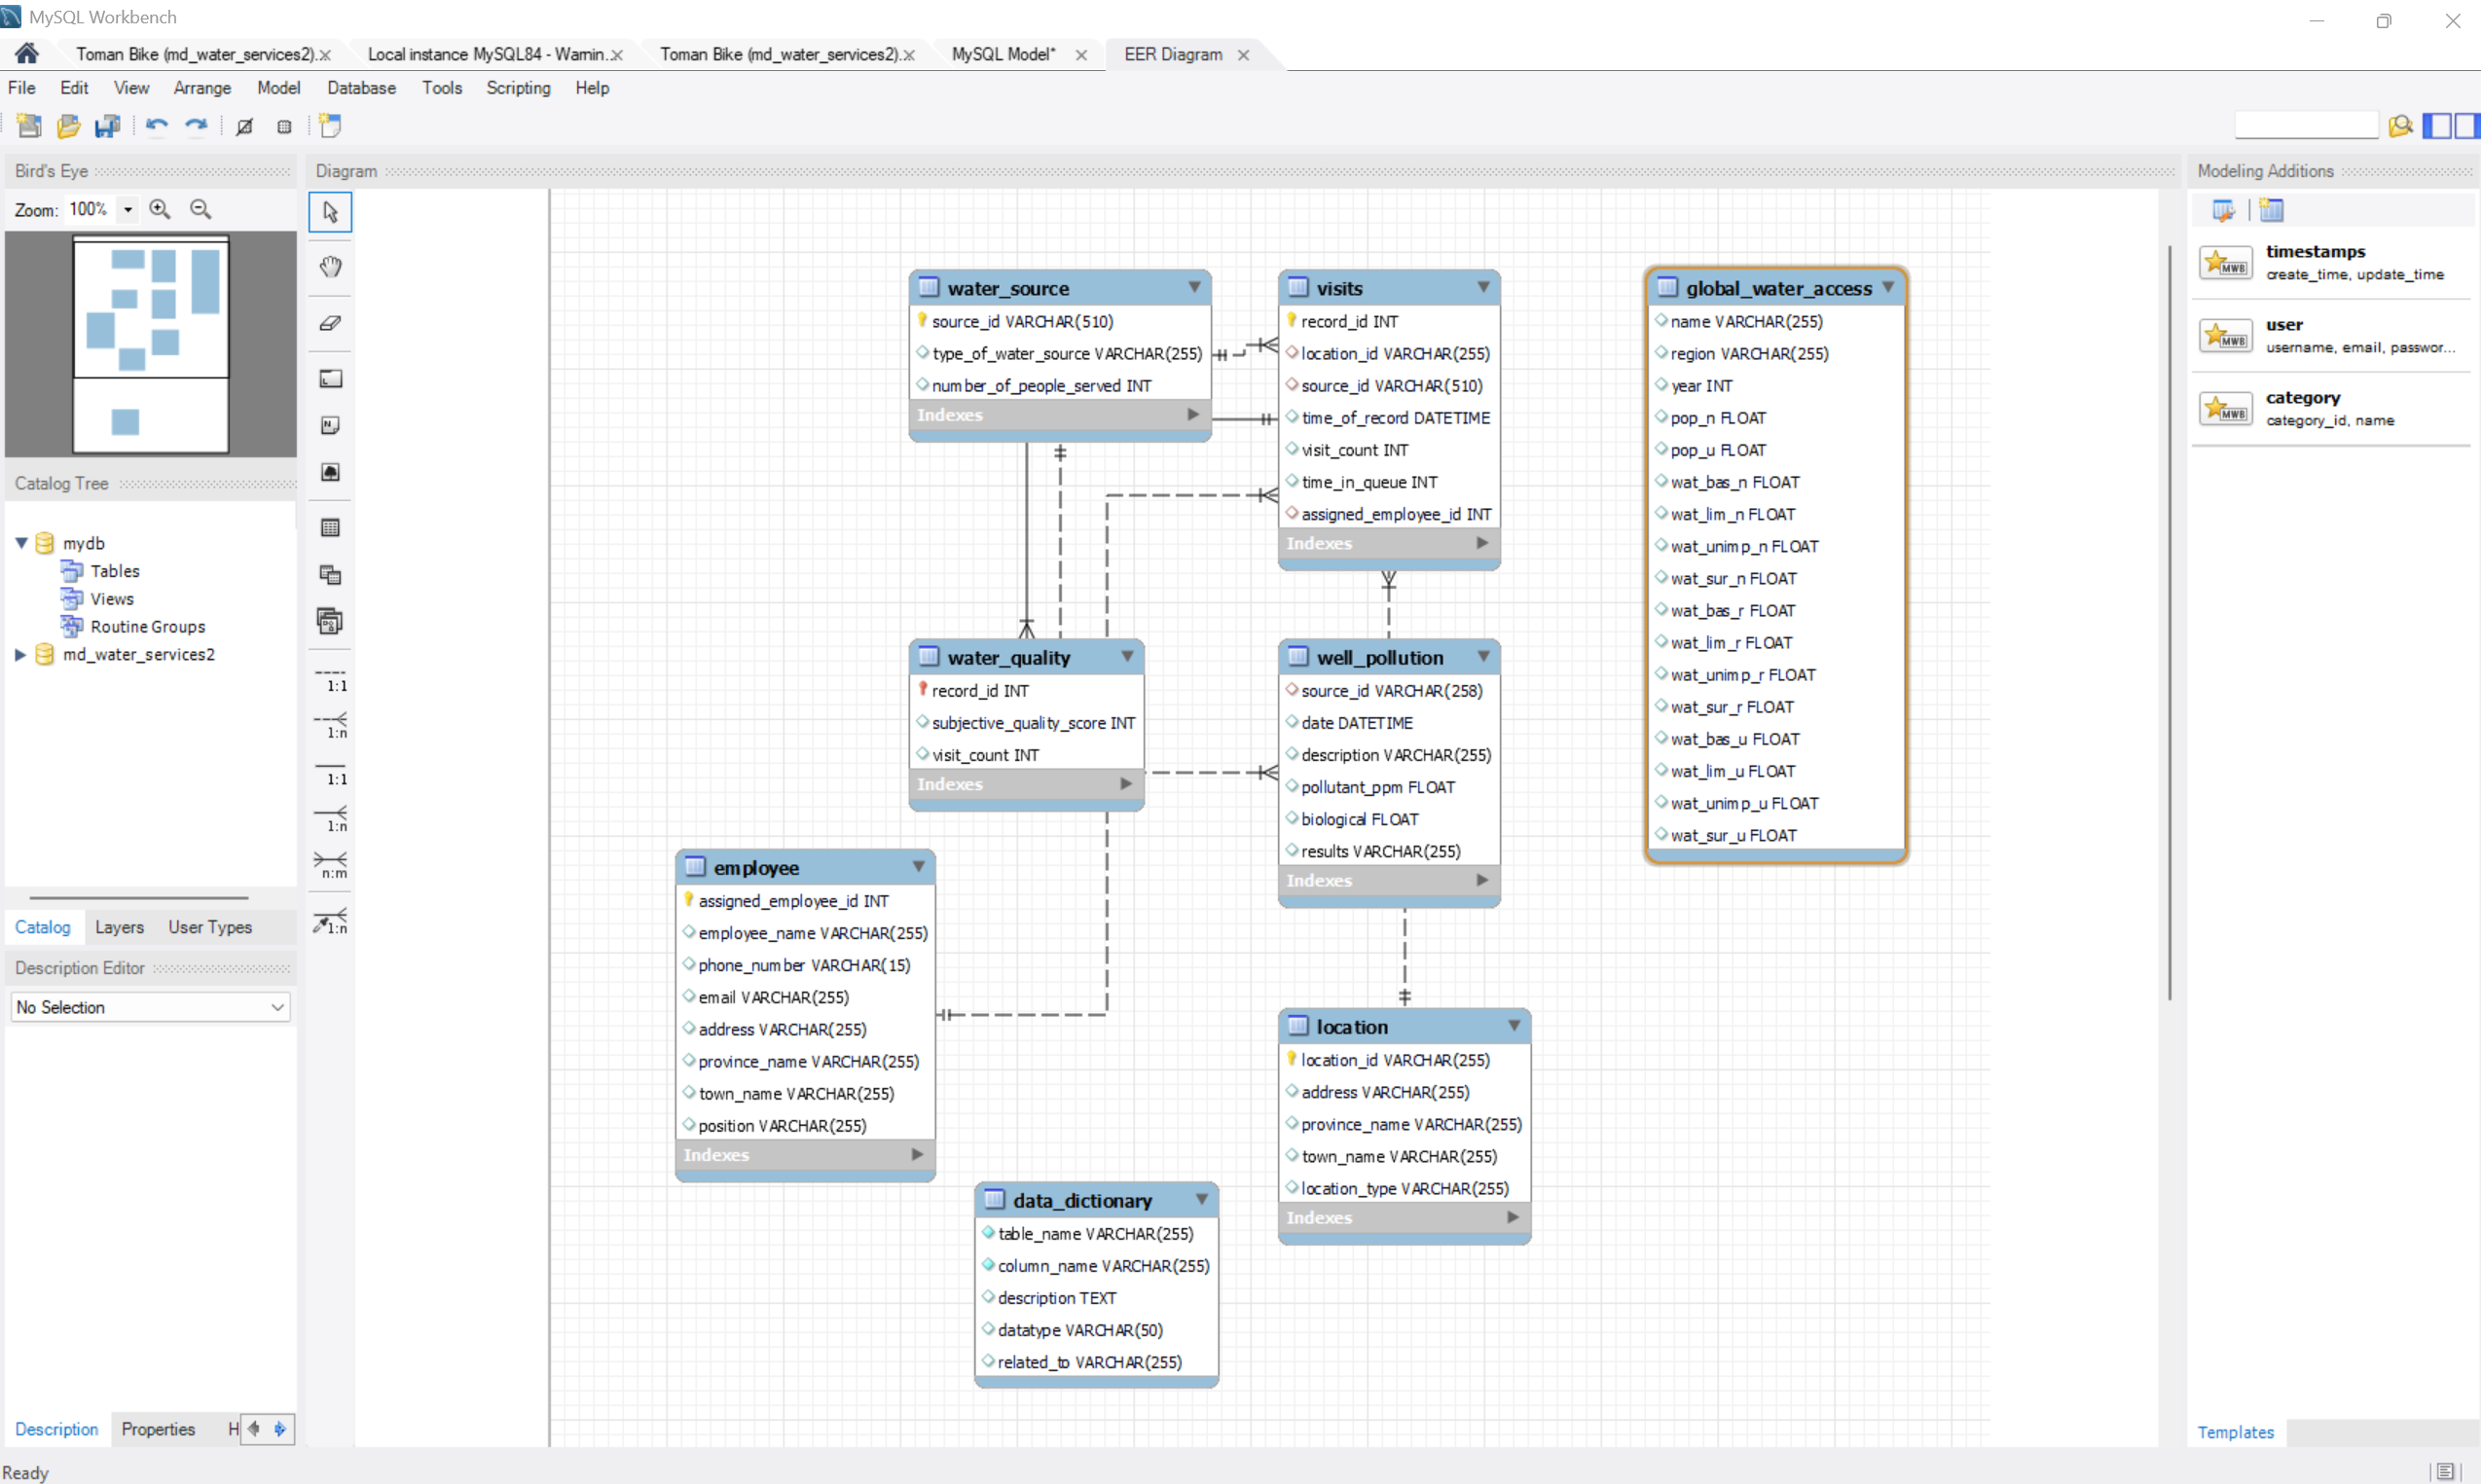

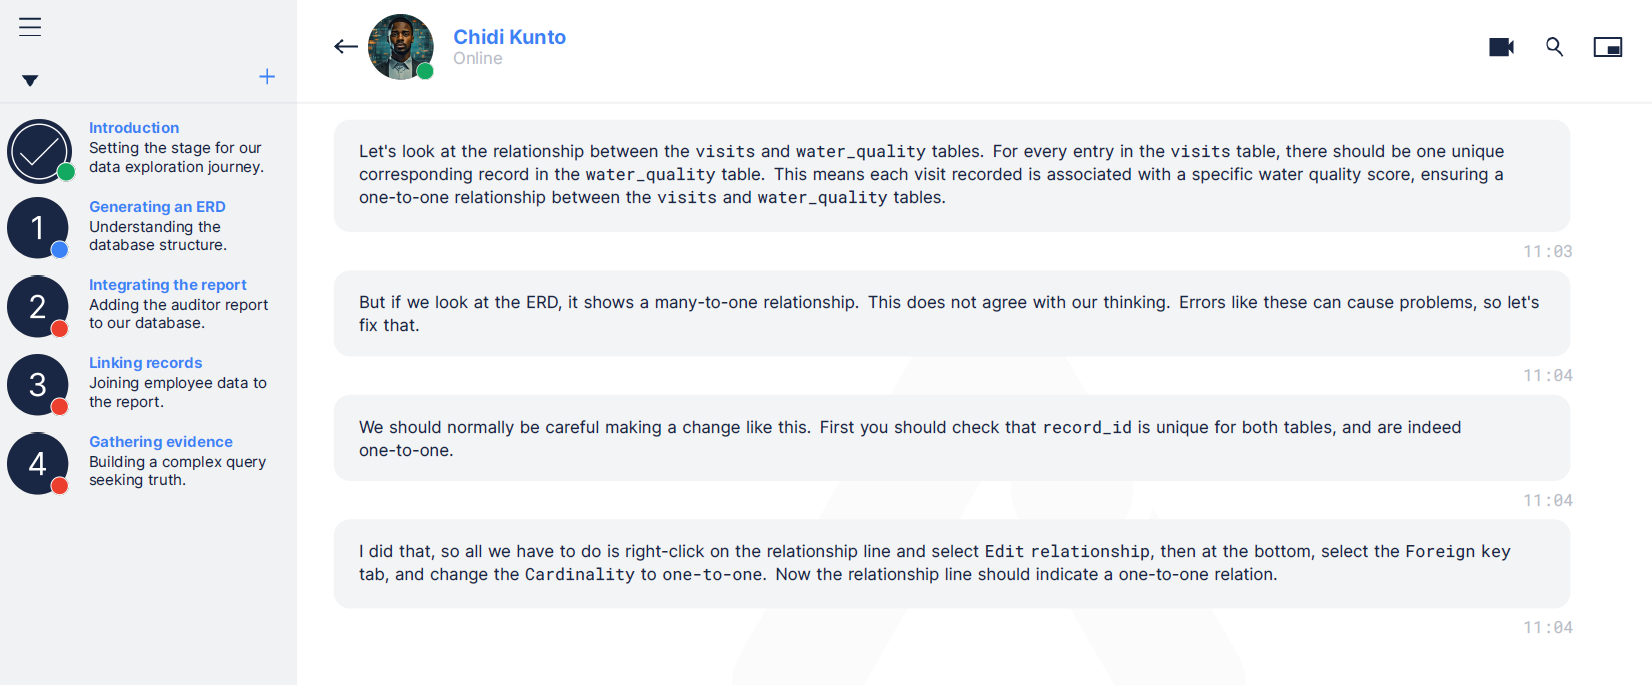

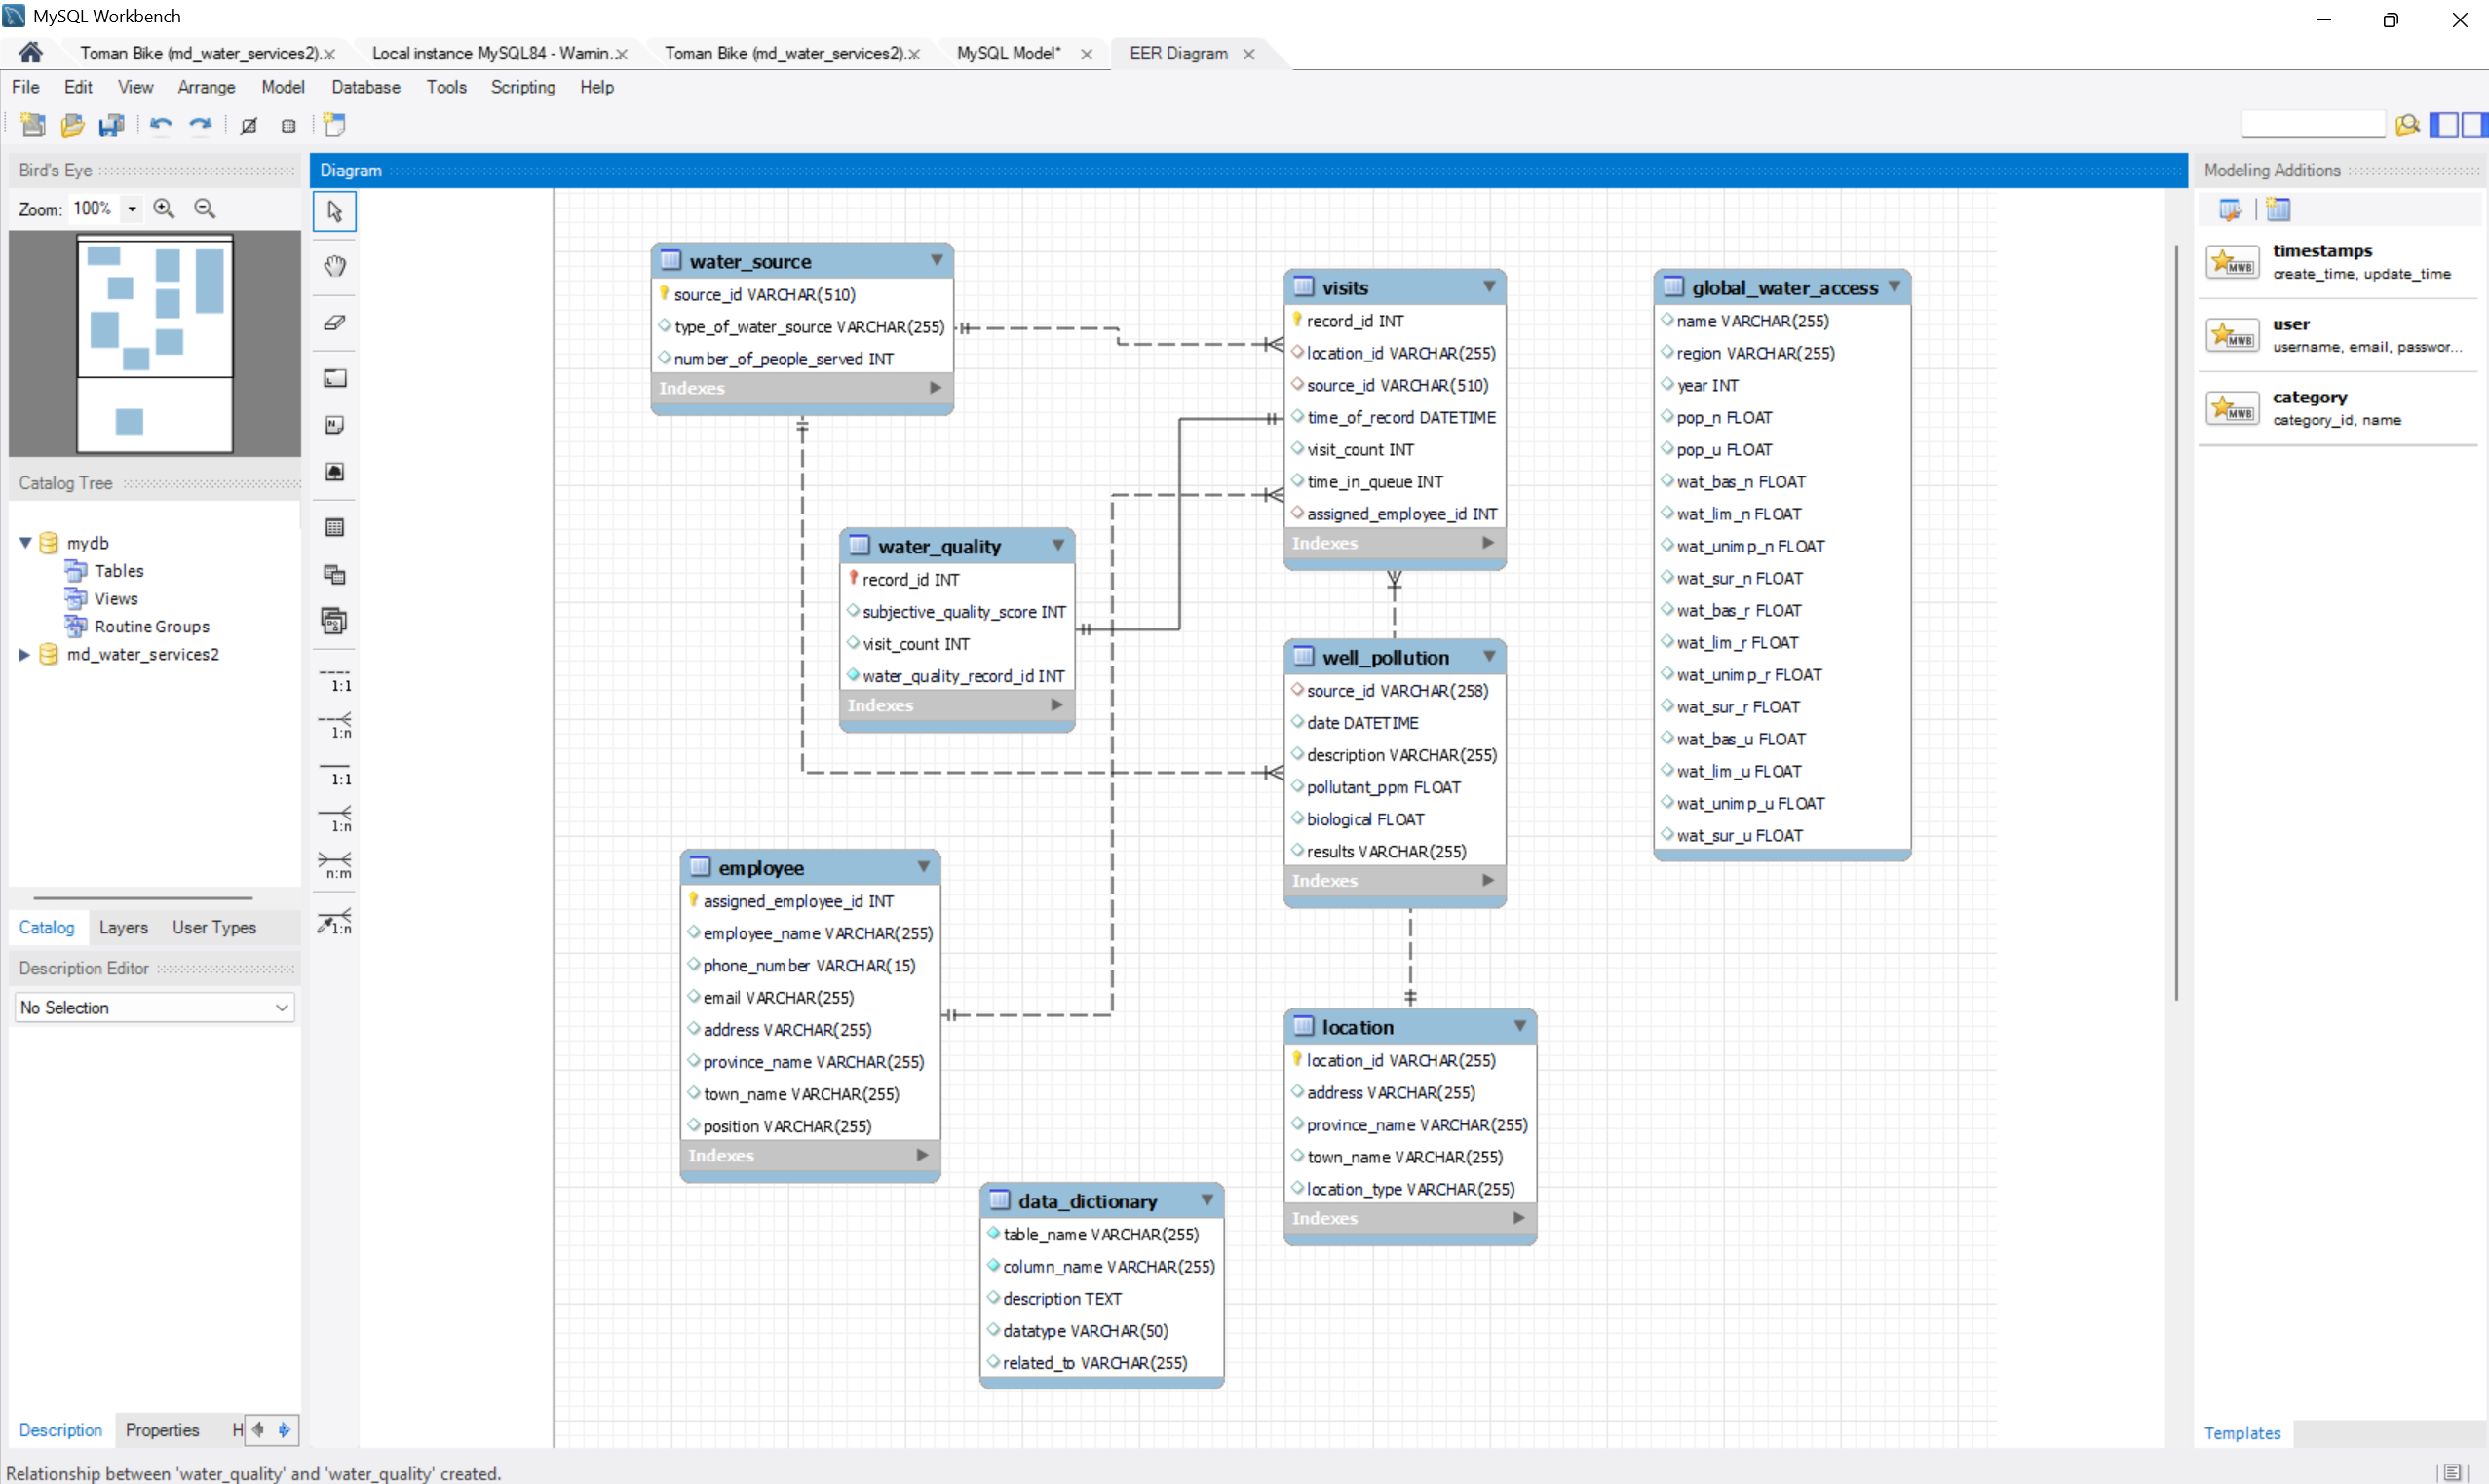

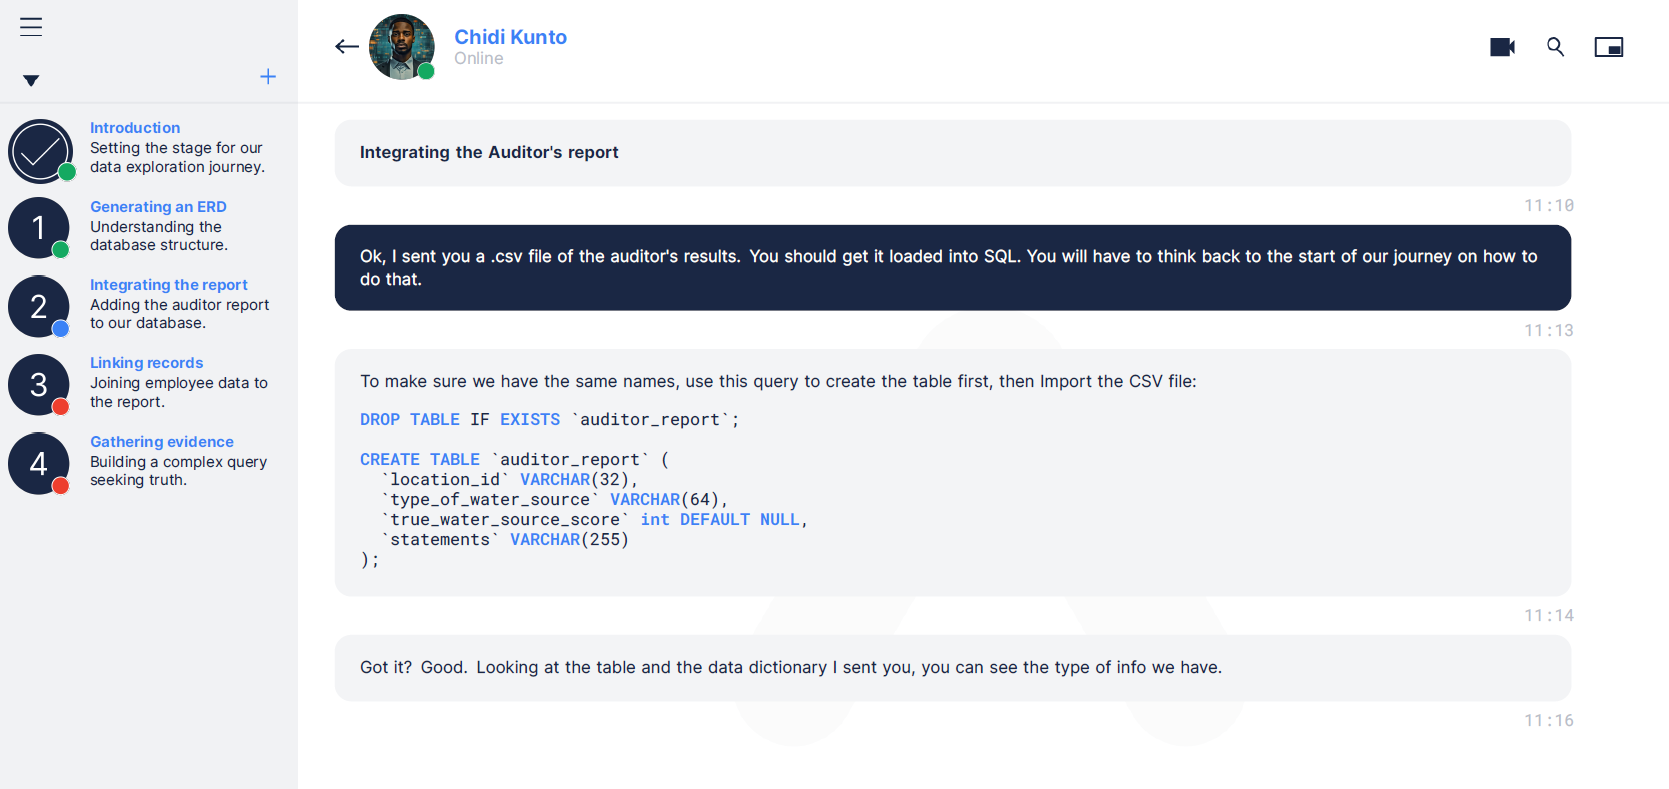

In [ ]:
%%sql
DROP TABLE IF EXISTS `auditor_report`;
CREATE TABLE `auditor_report` (
`location_id` VARCHAR(32),
`type_of_water_source` VARCHAR(64),
`true_water_source_score` int DEFAULT NULL,
`statements` VARCHAR(255)
);

In [ ]:
%%sql
SHOW TABLES;

### ERD After Including Auditor Report Table

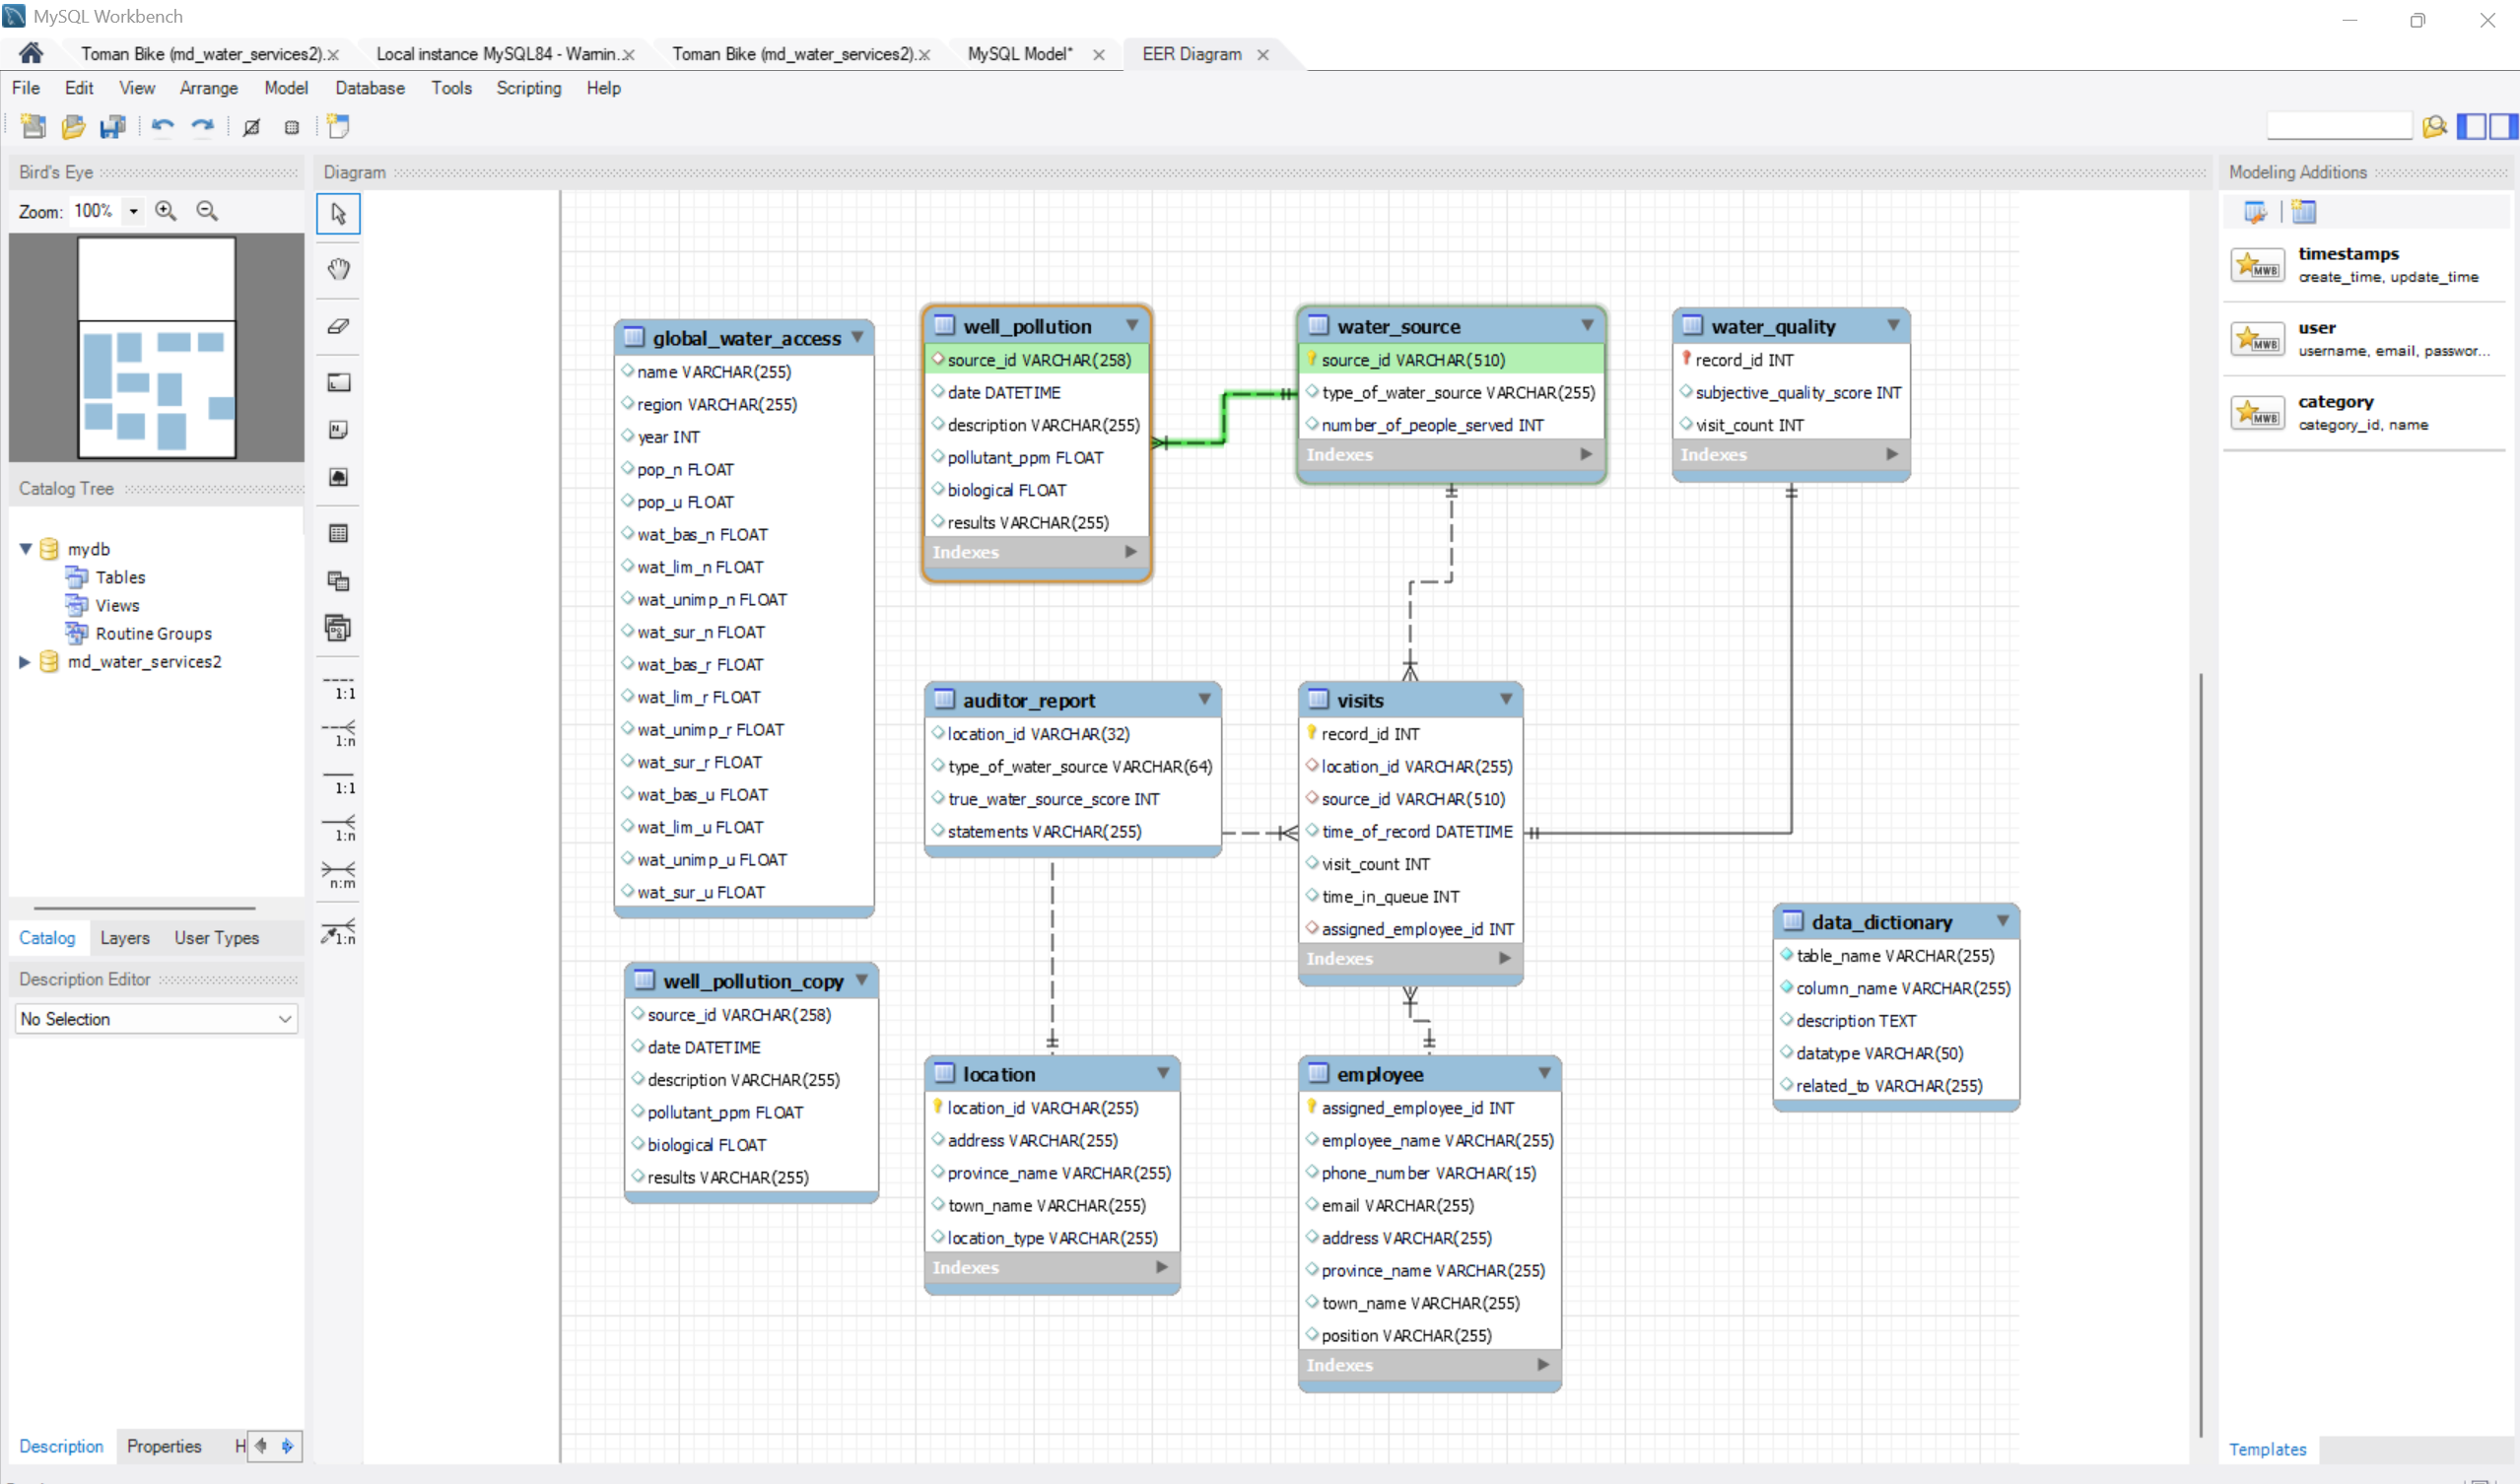

In [ ]:
%%sql
SELECT COUNT(*) FROM auditor_report;

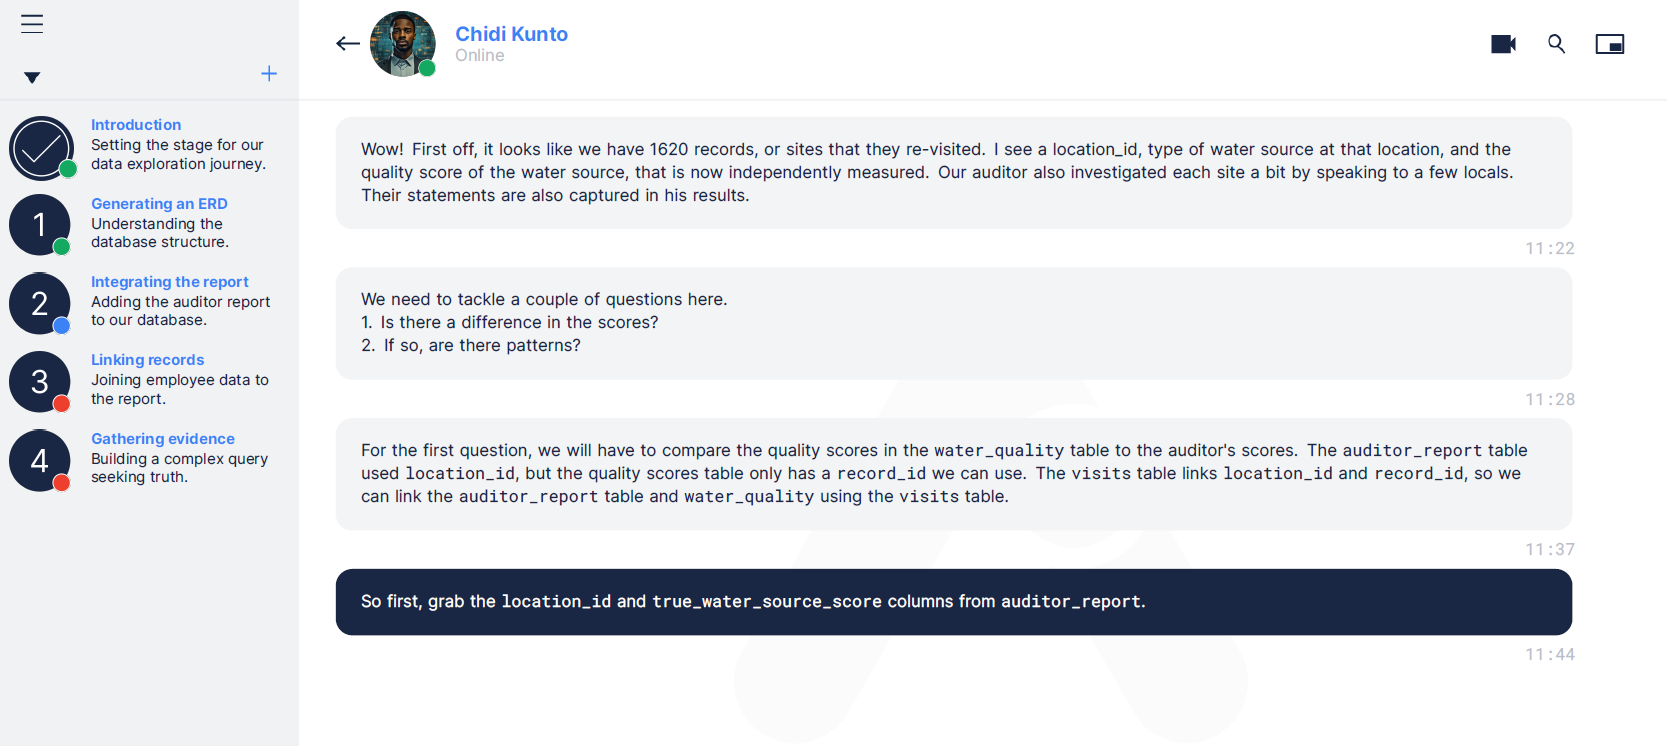

In [ ]:
%%sql
SELECT location_id, true_water_source_score FROM auditor_report ORDER BY location_id LIMIT 5;

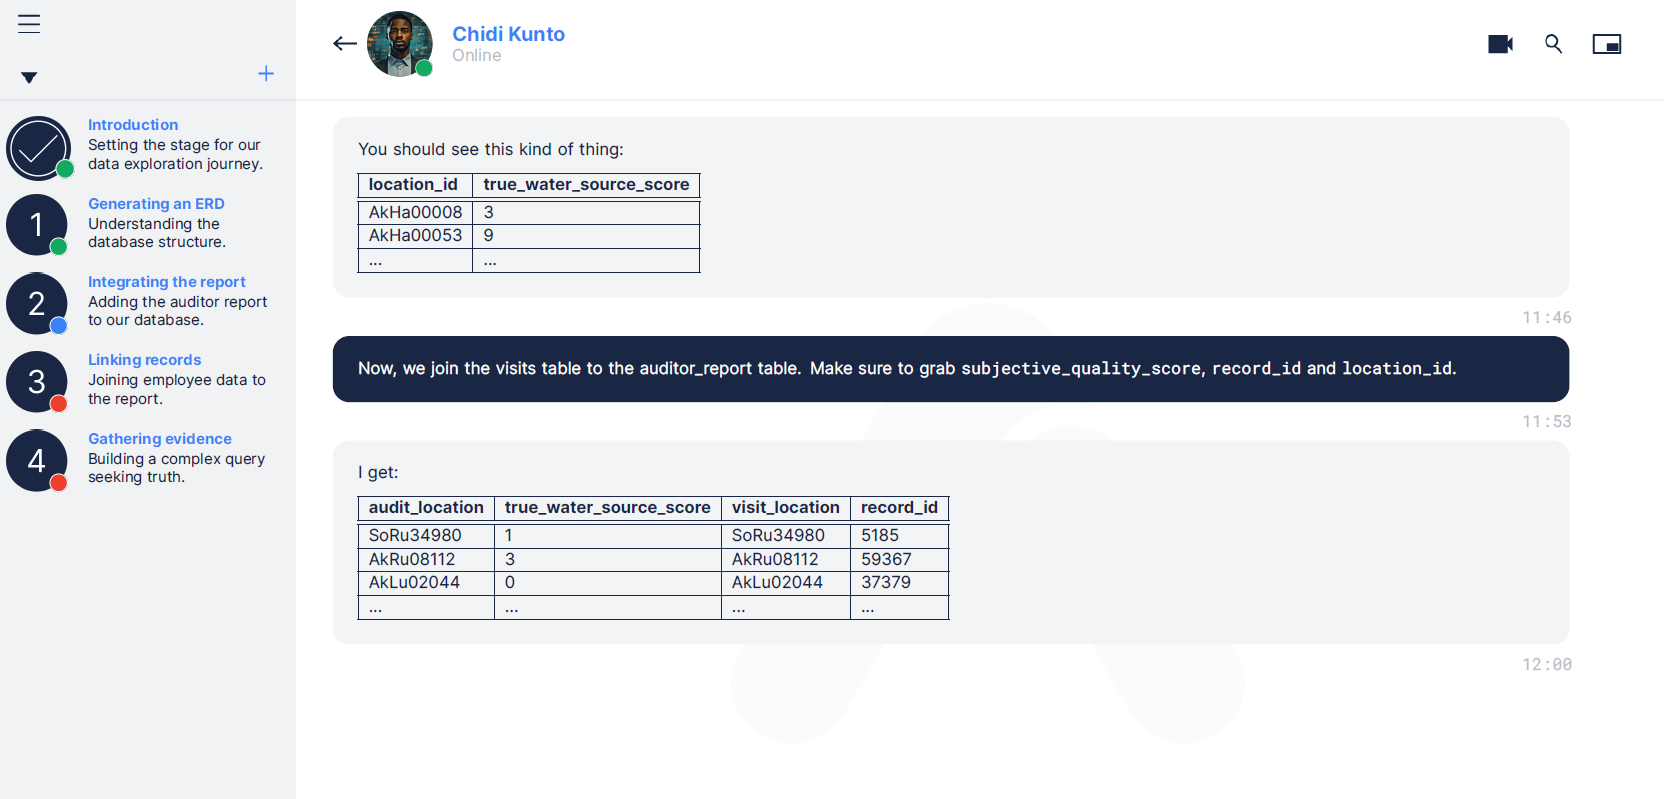

In [ ]:
%%sql
SELECT 
    a.location_id audit_location,
    a.true_water_source_score,
    v.location_id visit_location,
    v.record_id
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id;

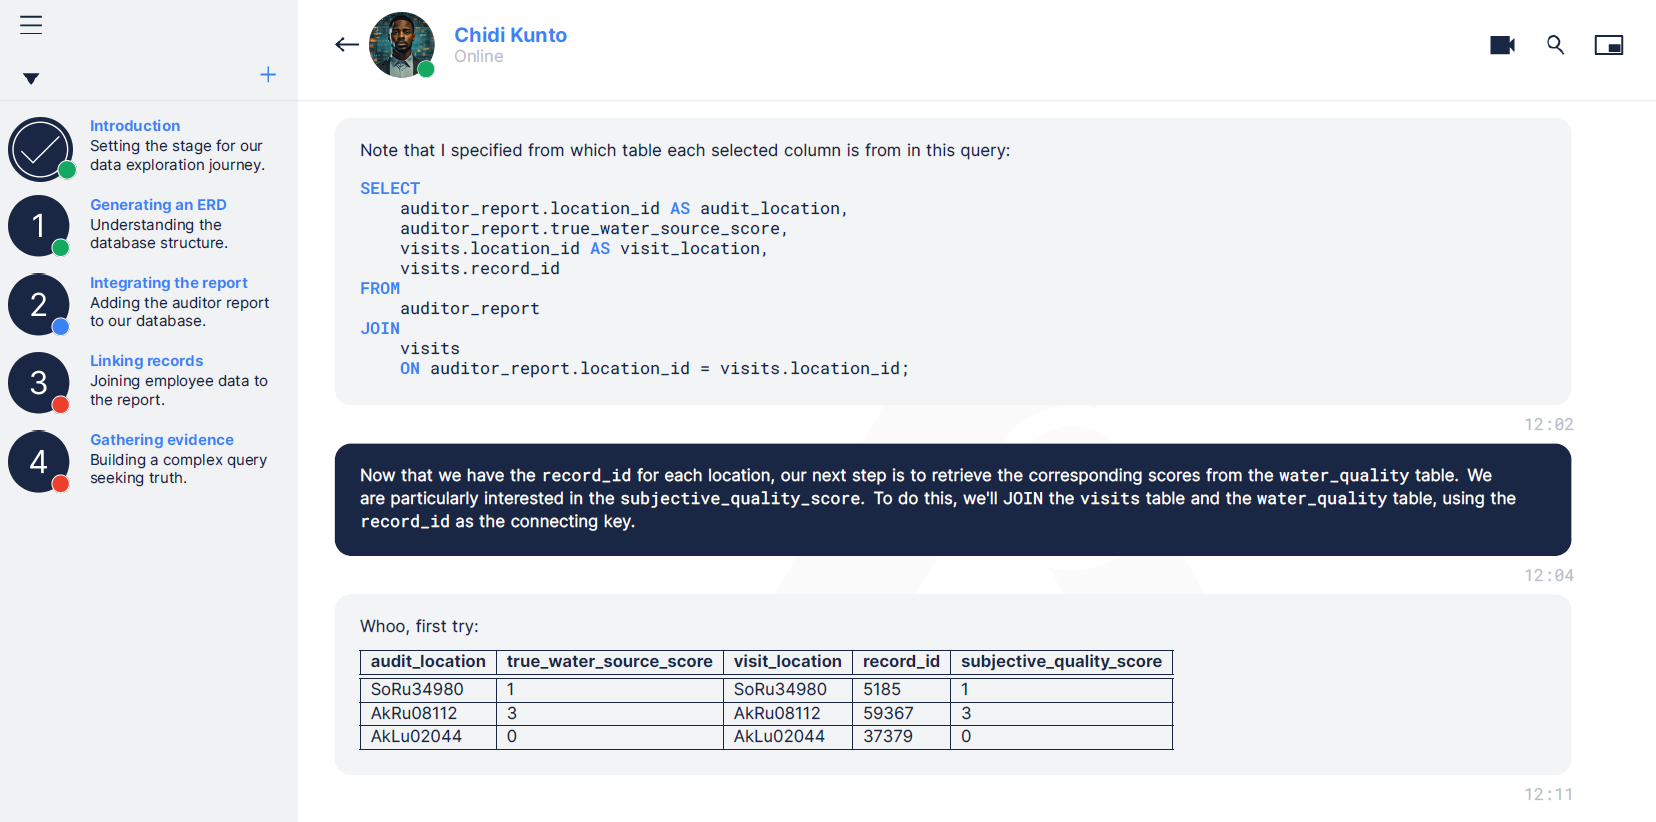

In [ ]:
%%sql
SELECT 
    a.location_id audit_location,
    a.true_water_source_score,
    v.location_id visit_location,
    v.record_id,
    w.subjective_quality_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id;

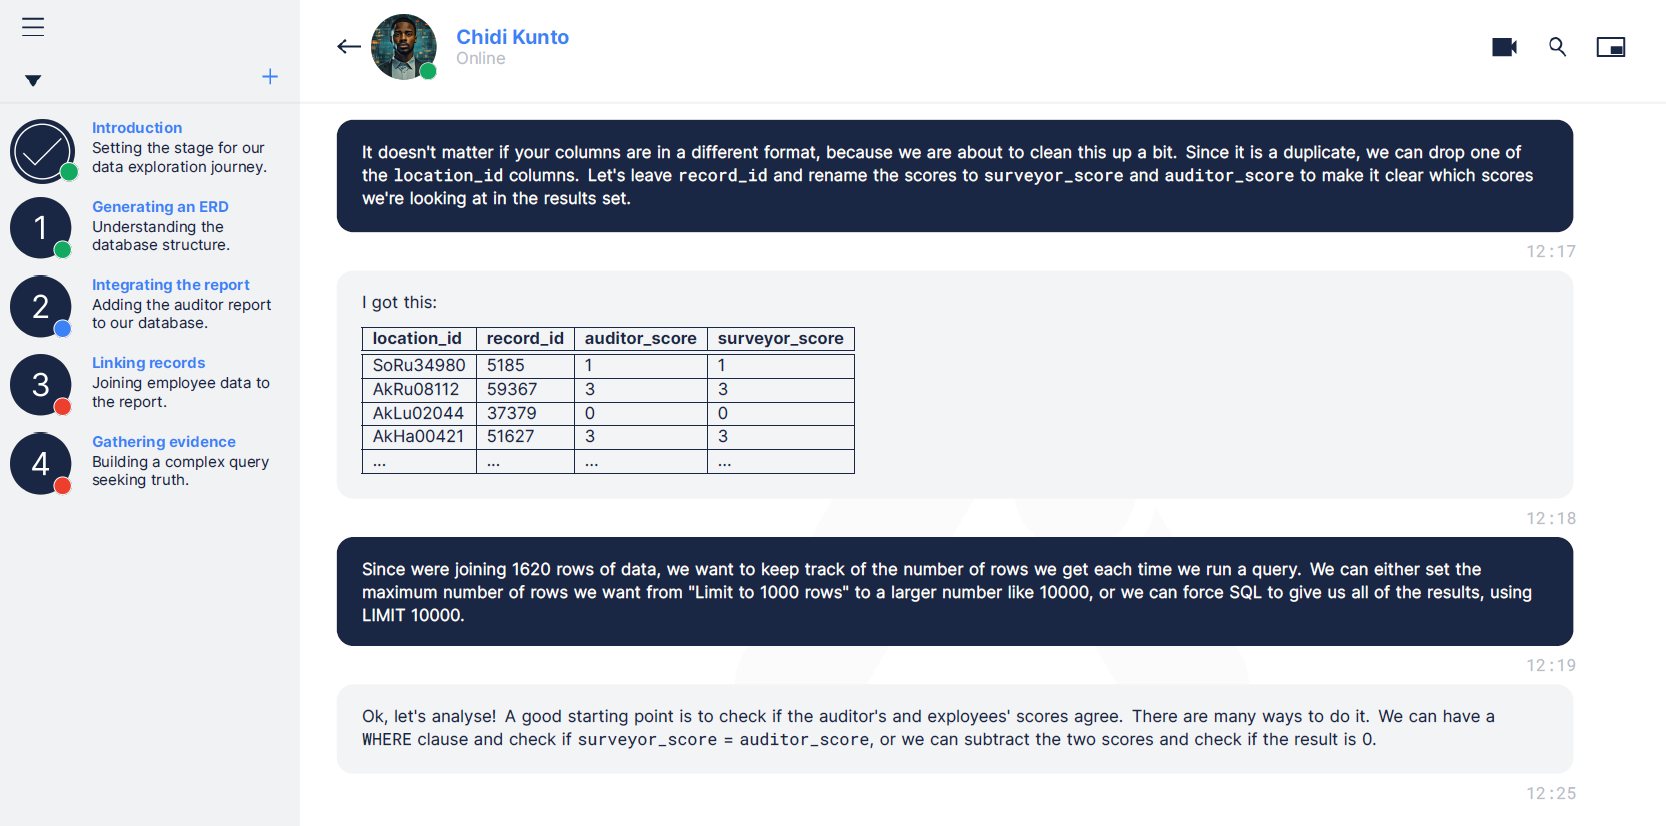

In [ ]:
%%sql
SELECT 
    a.location_id,
    a.true_water_source_score,
    v.record_id,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
WHERE w.subjective_quality_score = a.true_water_source_score LIMIT 5;

In [ ]:
%%sql
WITH matched_scores AS (
SELECT 
    a.location_id,
    a.true_water_source_score,
    v.record_id,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
WHERE w.subjective_quality_score = a.true_water_source_score )
SELECT COUNT(*) FROM matched_scores;

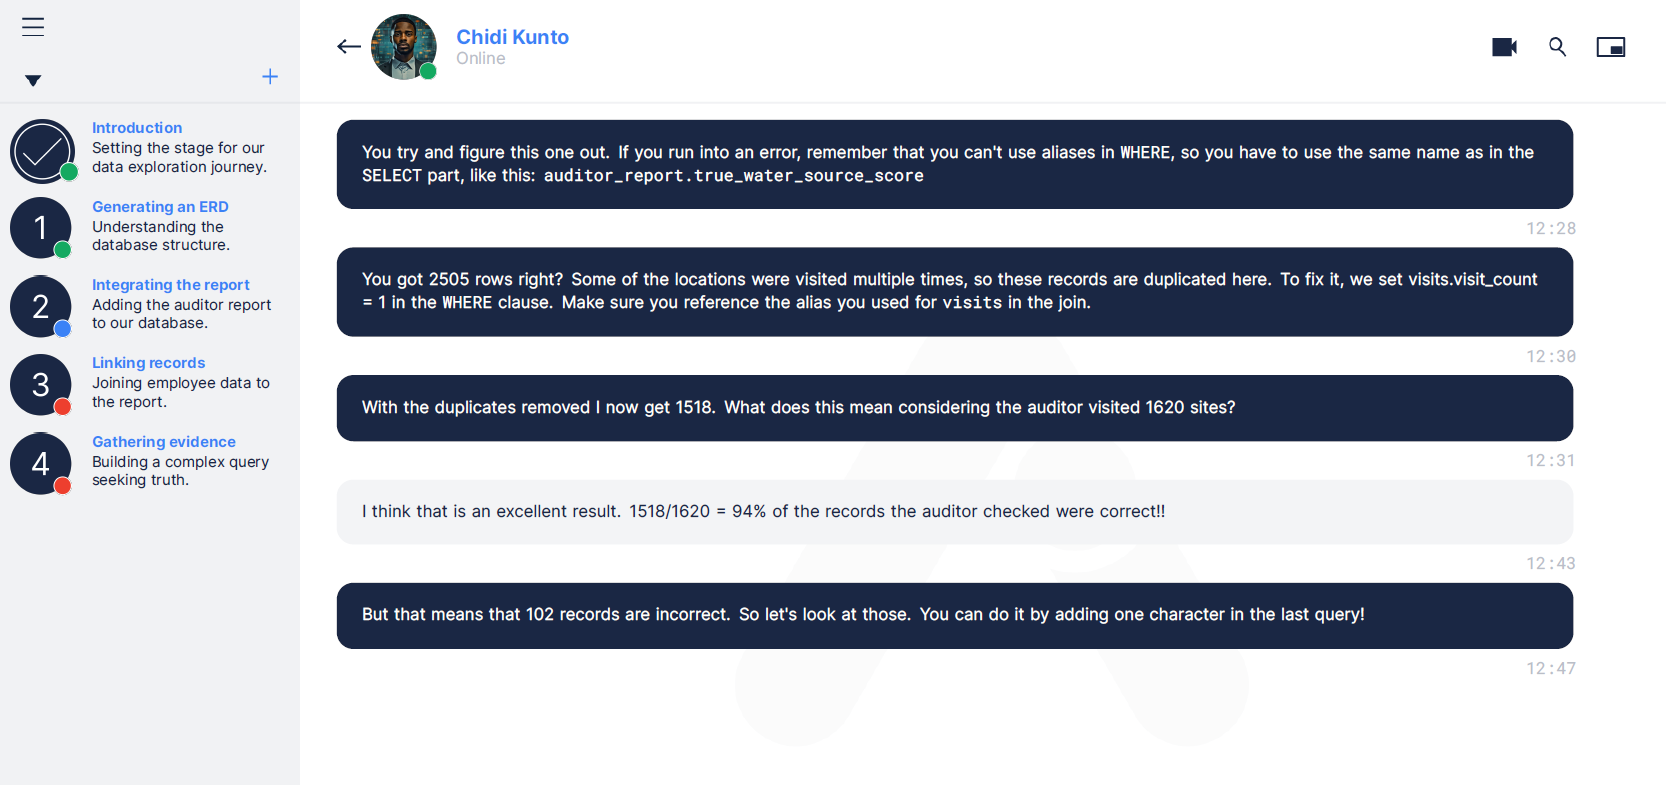

In [ ]:
%%sql
WITH matched_scores AS (
SELECT 
    a.location_id,
    a.true_water_source_score,
    v.record_id,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
WHERE w.subjective_quality_score = a.true_water_source_score AND v.visit_count = 1)
SELECT COUNT(*) FROM matched_scores;

#### But that means that 102 records are incorrect. So let's look at those. You can do it by adding one character in the last query!

In [ ]:
%%sql
SELECT 
    a.location_id,
    a.true_water_source_score,
    v.record_id,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1
LIMIT 5;

In [ ]:
%%sql
WITH unmatched_scores AS (
SELECT 
    a.location_id,
    a.true_water_source_score,
    v.record_id,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1)
SELECT COUNT(*) FROM unmatched_scores;

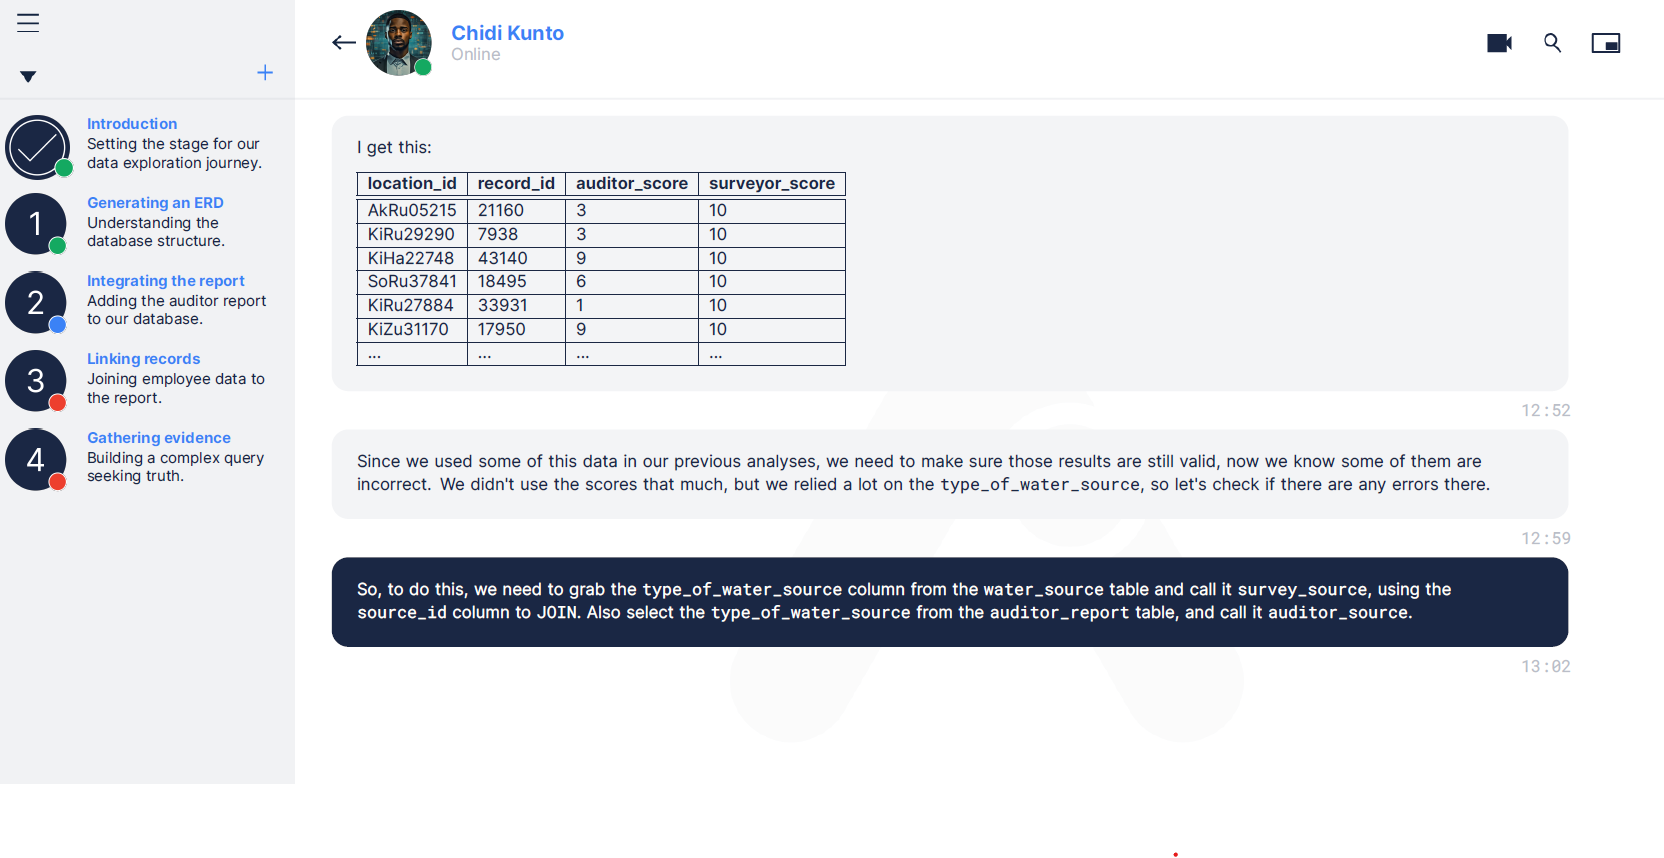

In [ ]:
%%sql
SELECT 
    a.location_id,
    a.type_of_water_source AS audit_source,
    s.type_of_water_source AS survey_source,
    v.record_id,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN water_source s ON v.source_id = s.source_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1 LIMIT 5;


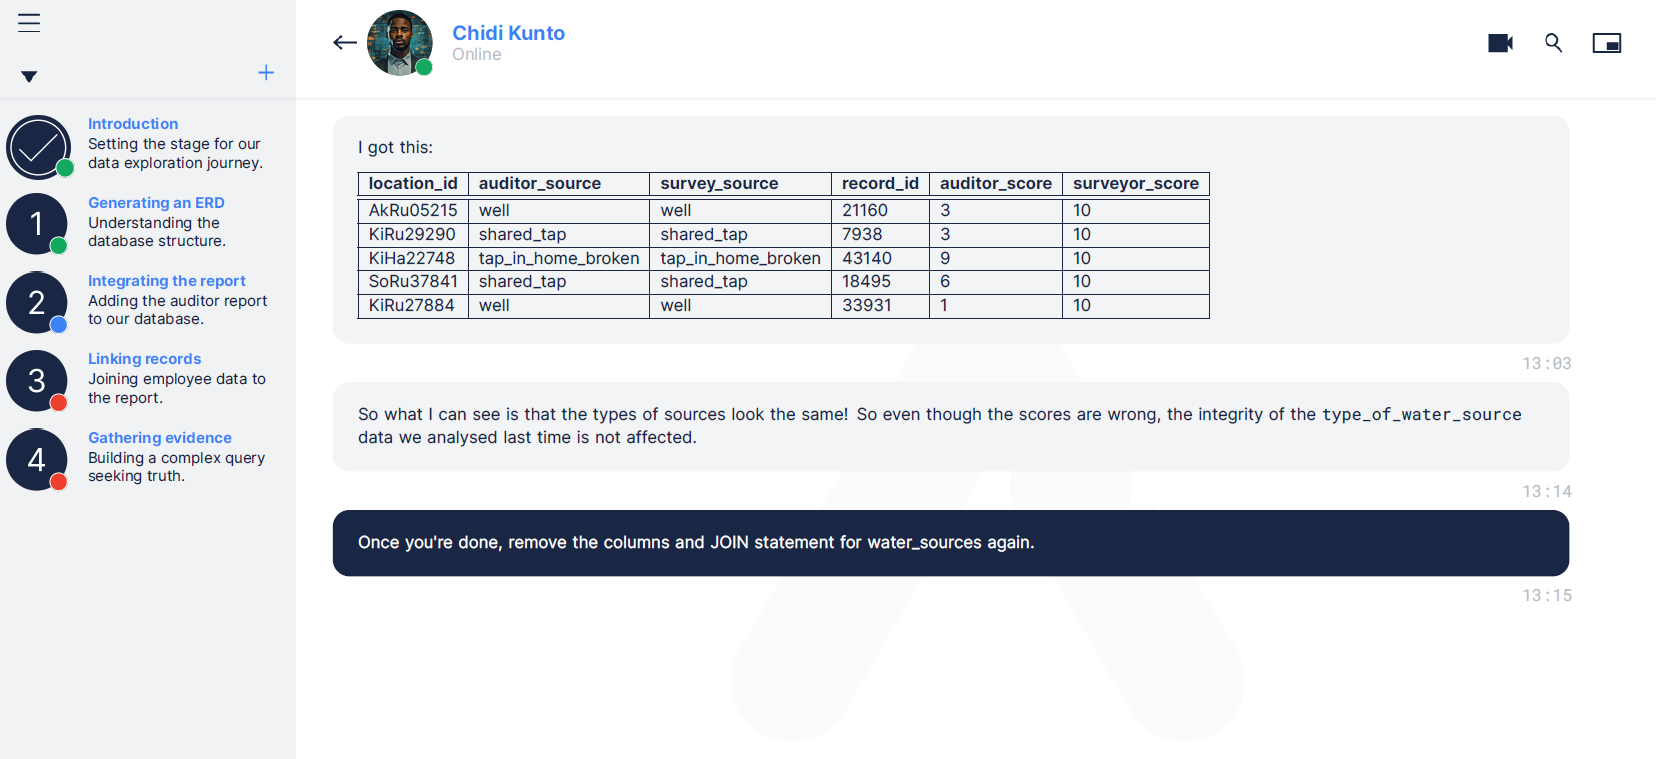

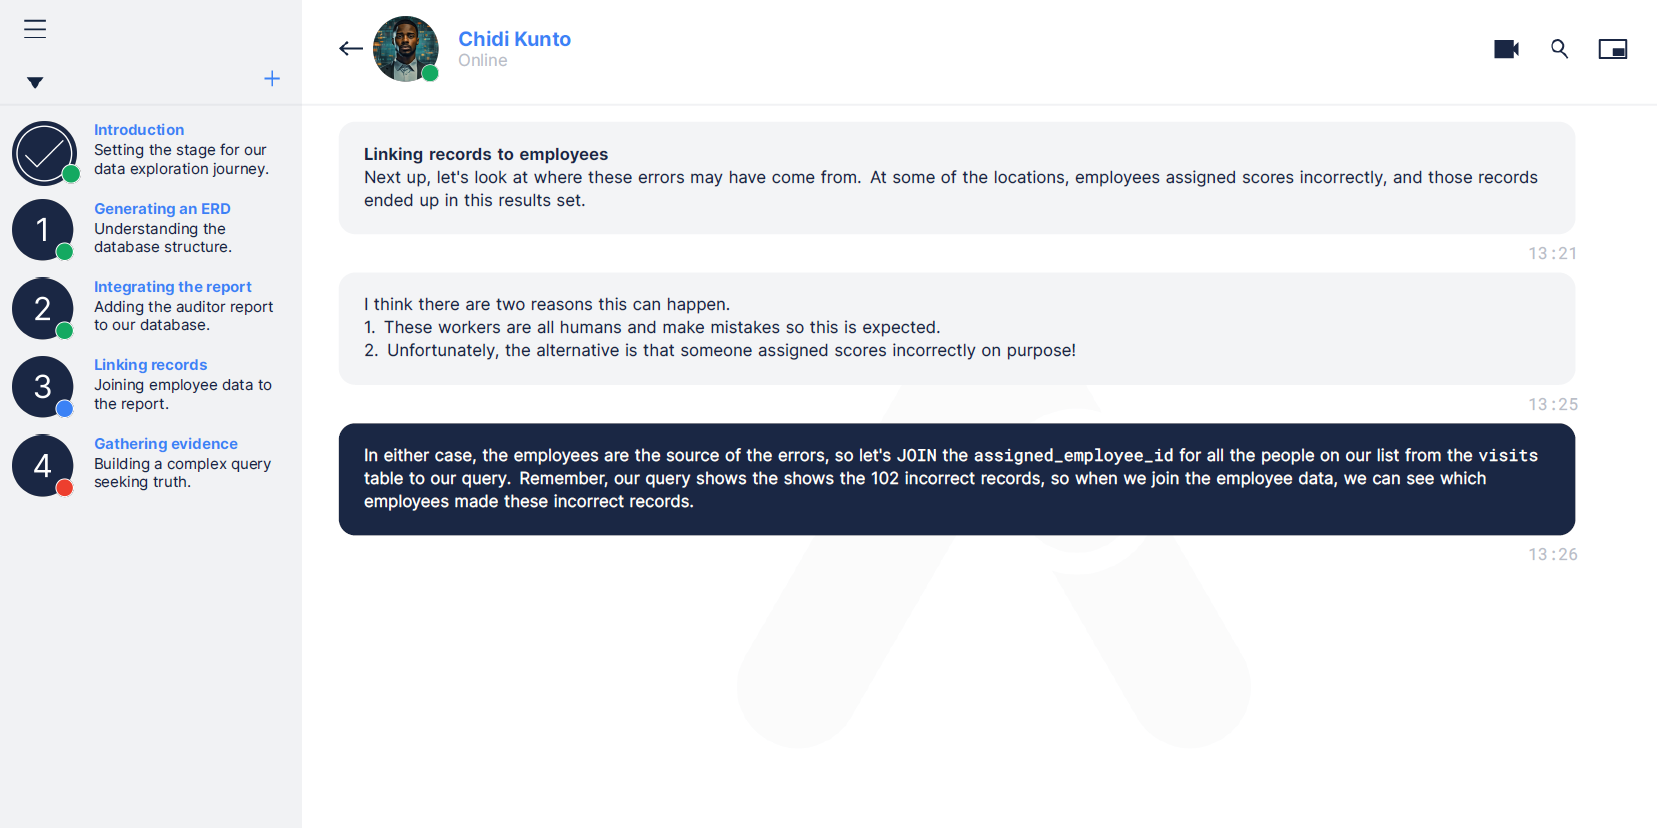

In [ ]:
%%sql
SELECT 
    a.location_id,
    v.record_id,
    v.assigned_employee_id,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN employee e ON v.assigned_employee_id = e.assigned_employee_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1 LIMIT 5;


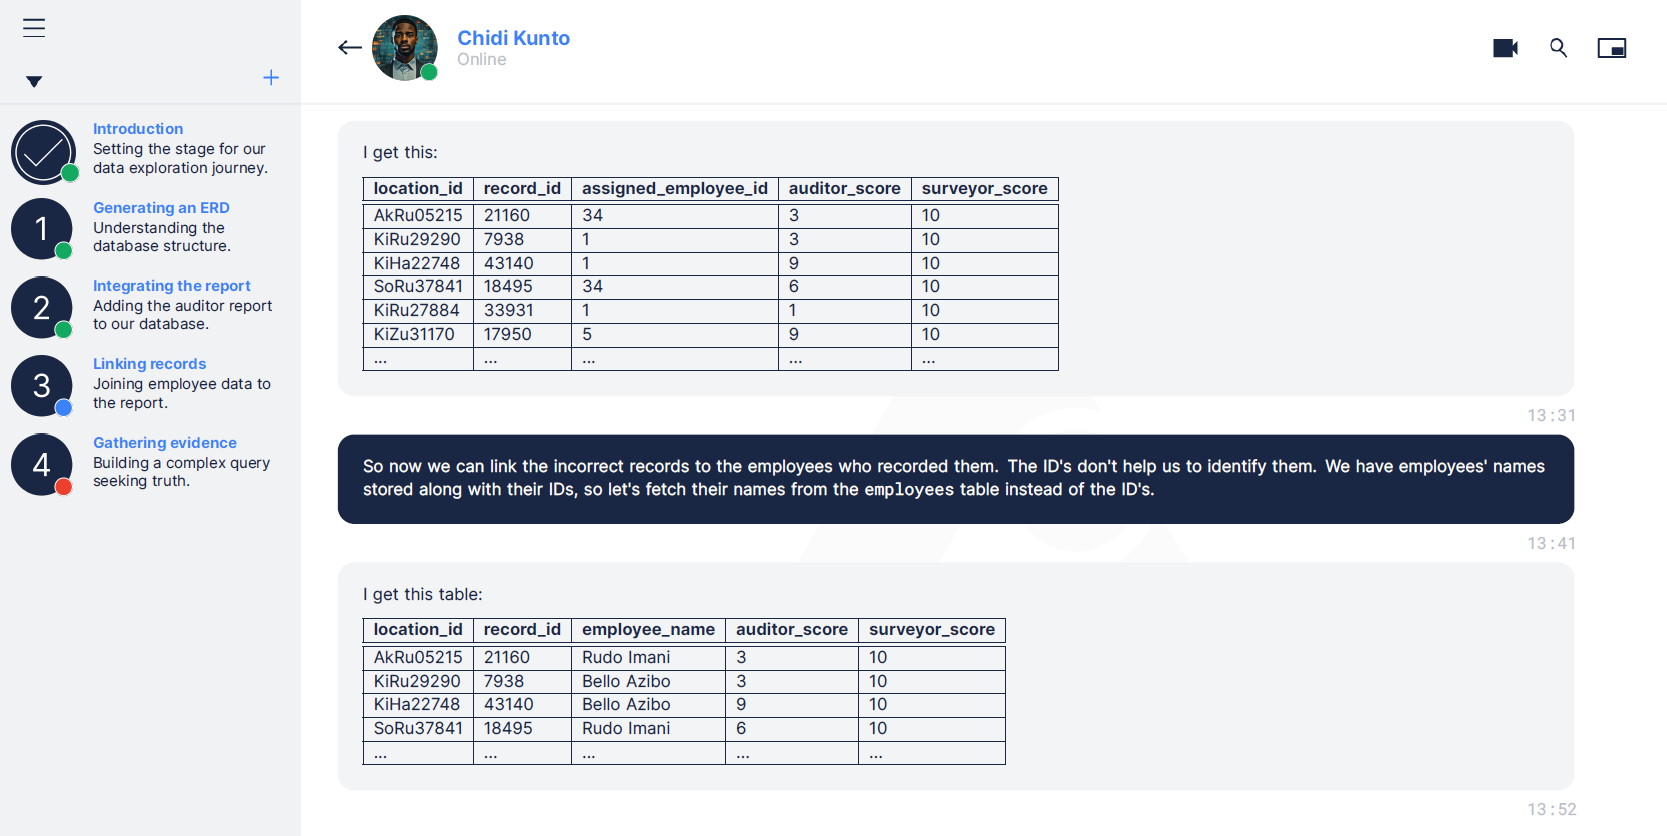

In [ ]:
%%sql
SELECT 
    a.location_id,
    v.record_id,
    e.employee_name,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN employee e ON v.assigned_employee_id = e.assigned_employee_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1 LIMIT 5;


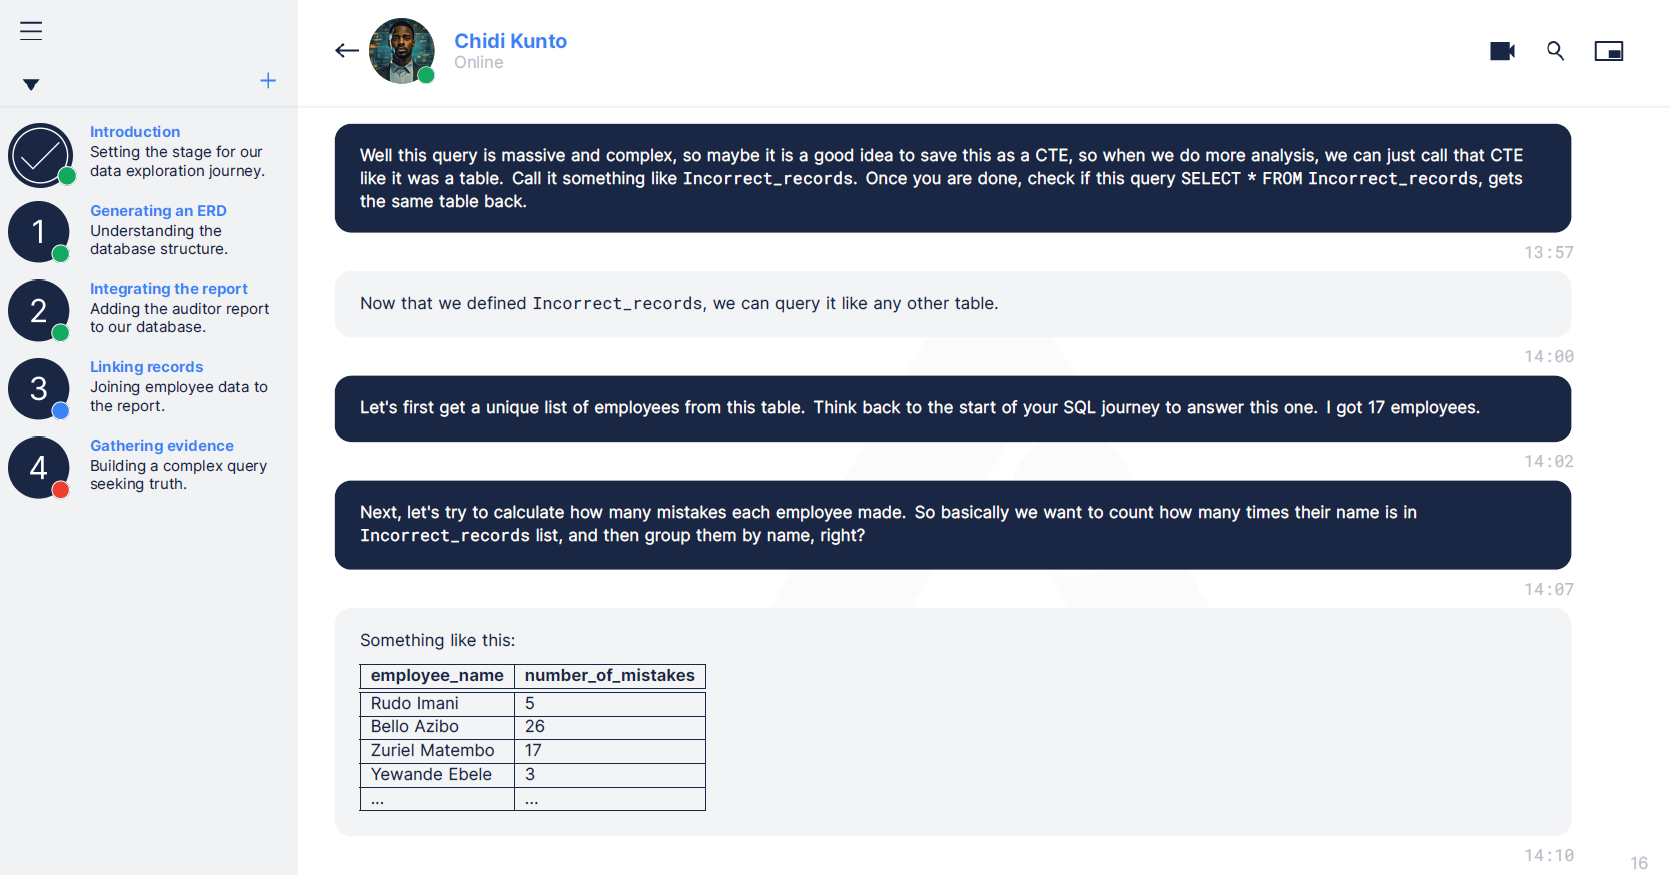

In [ ]:
%%sql
WITH incorrect_records AS (
SELECT 
    a.location_id,
    v.record_id,
    e.employee_name,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN employee e ON v.assigned_employee_id = e.assigned_employee_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1)
SELECT COUNT(*) FROM incorrect_records;


#### Get Unique list of employees

In [ ]:
%%sql
WITH incorrect_records AS (
SELECT 
    a.location_id,
    v.record_id,
    e.employee_name employees,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN employee e ON v.assigned_employee_id = e.assigned_employee_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1)
SELECT Distinct employees FROM incorrect_records;


### Get number of mistakes per employees

In [ ]:
%%sql
WITH incorrect_records AS (
SELECT 
    a.location_id,
    v.record_id,
    e.employee_name employees,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN employee e ON v.assigned_employee_id = e.assigned_employee_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1)
SELECT 
    employees,
    COUNT(*) AS number_of_mistakes 
FROM incorrect_records
GROUP BY employees
ORDER BY number_of_mistakes DESC;


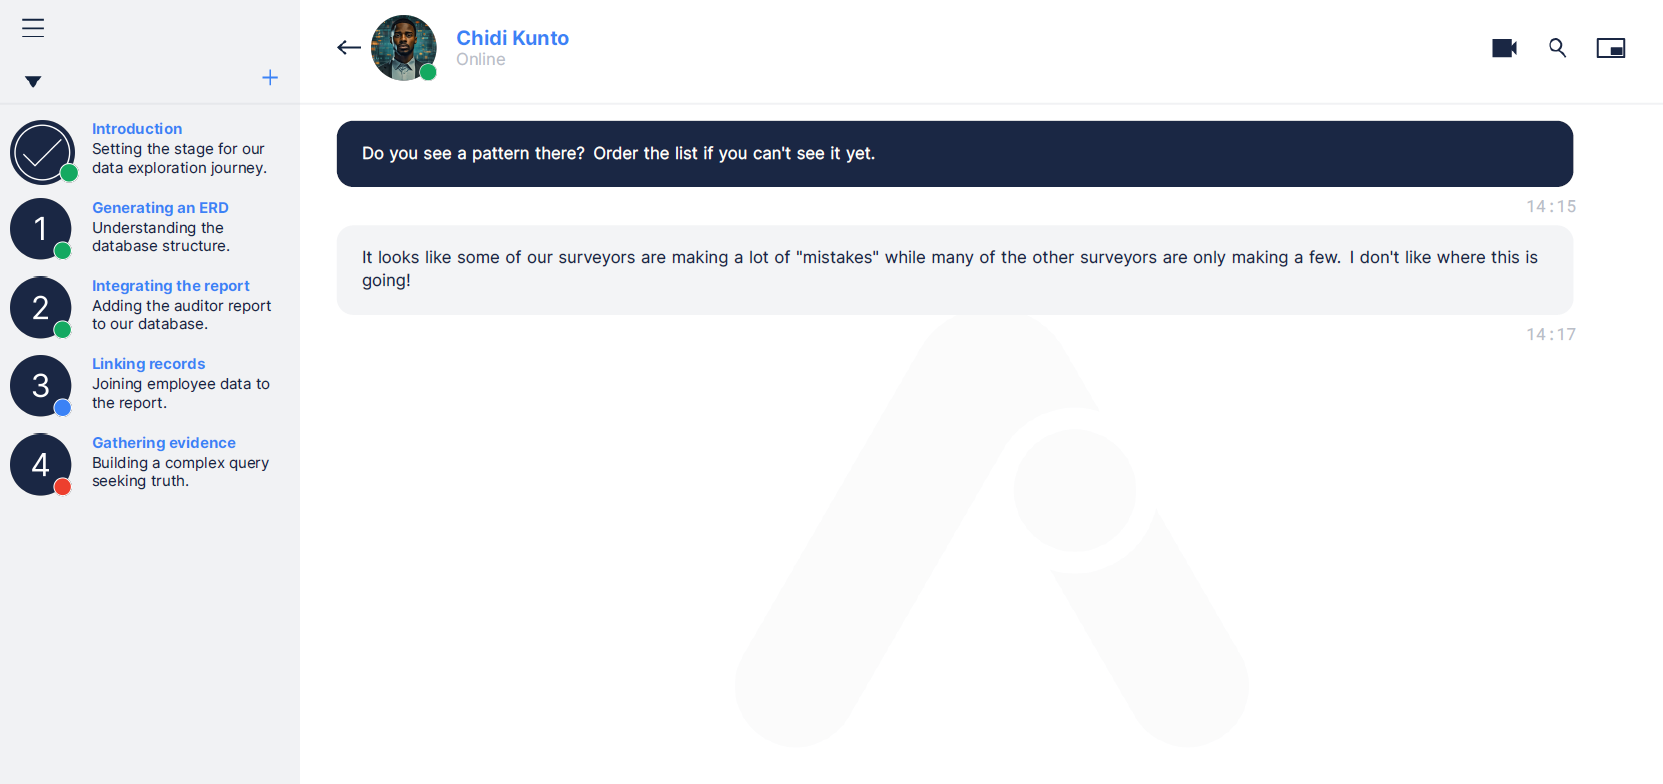

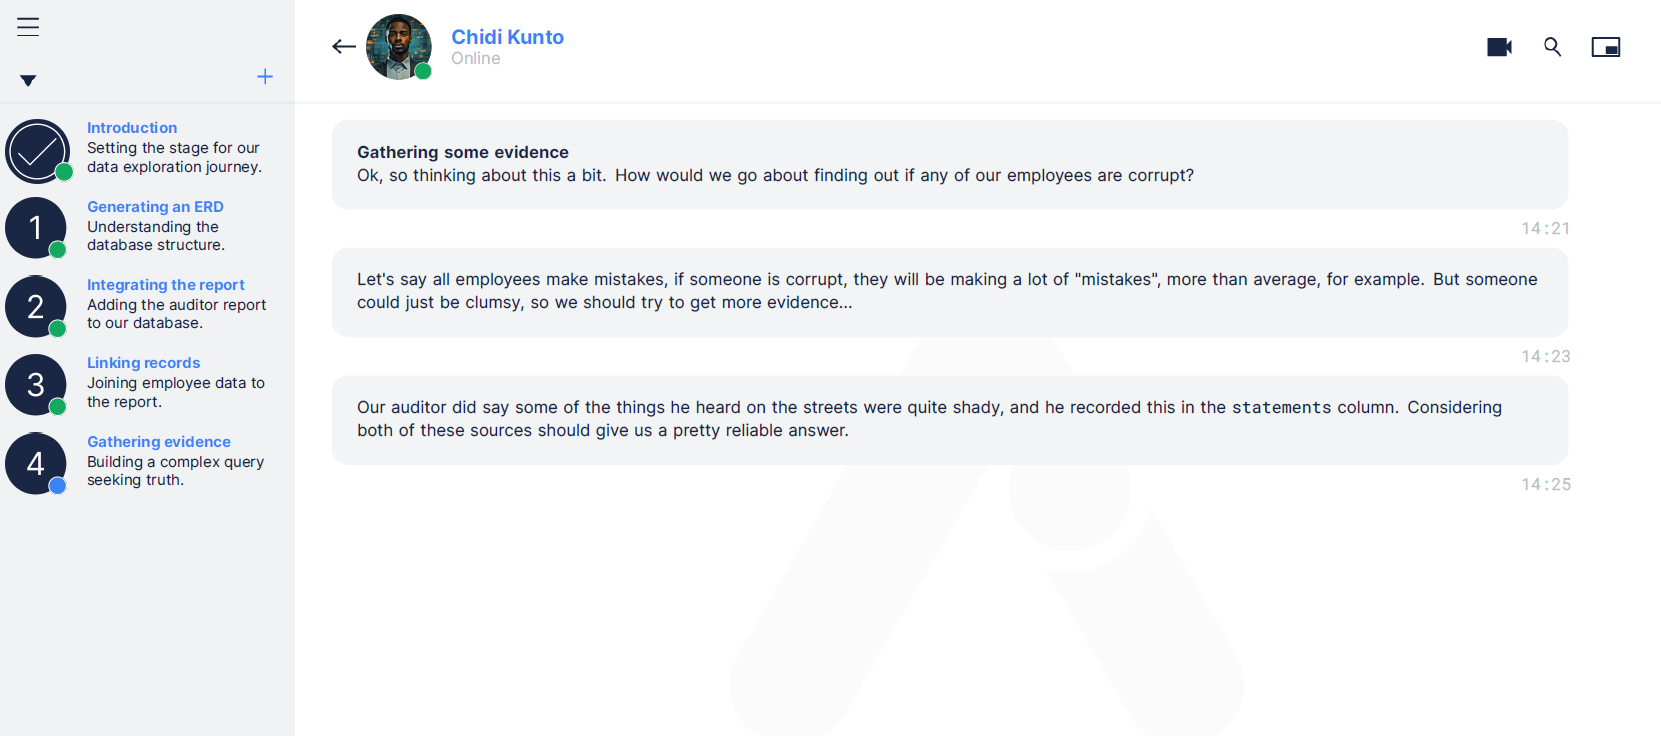

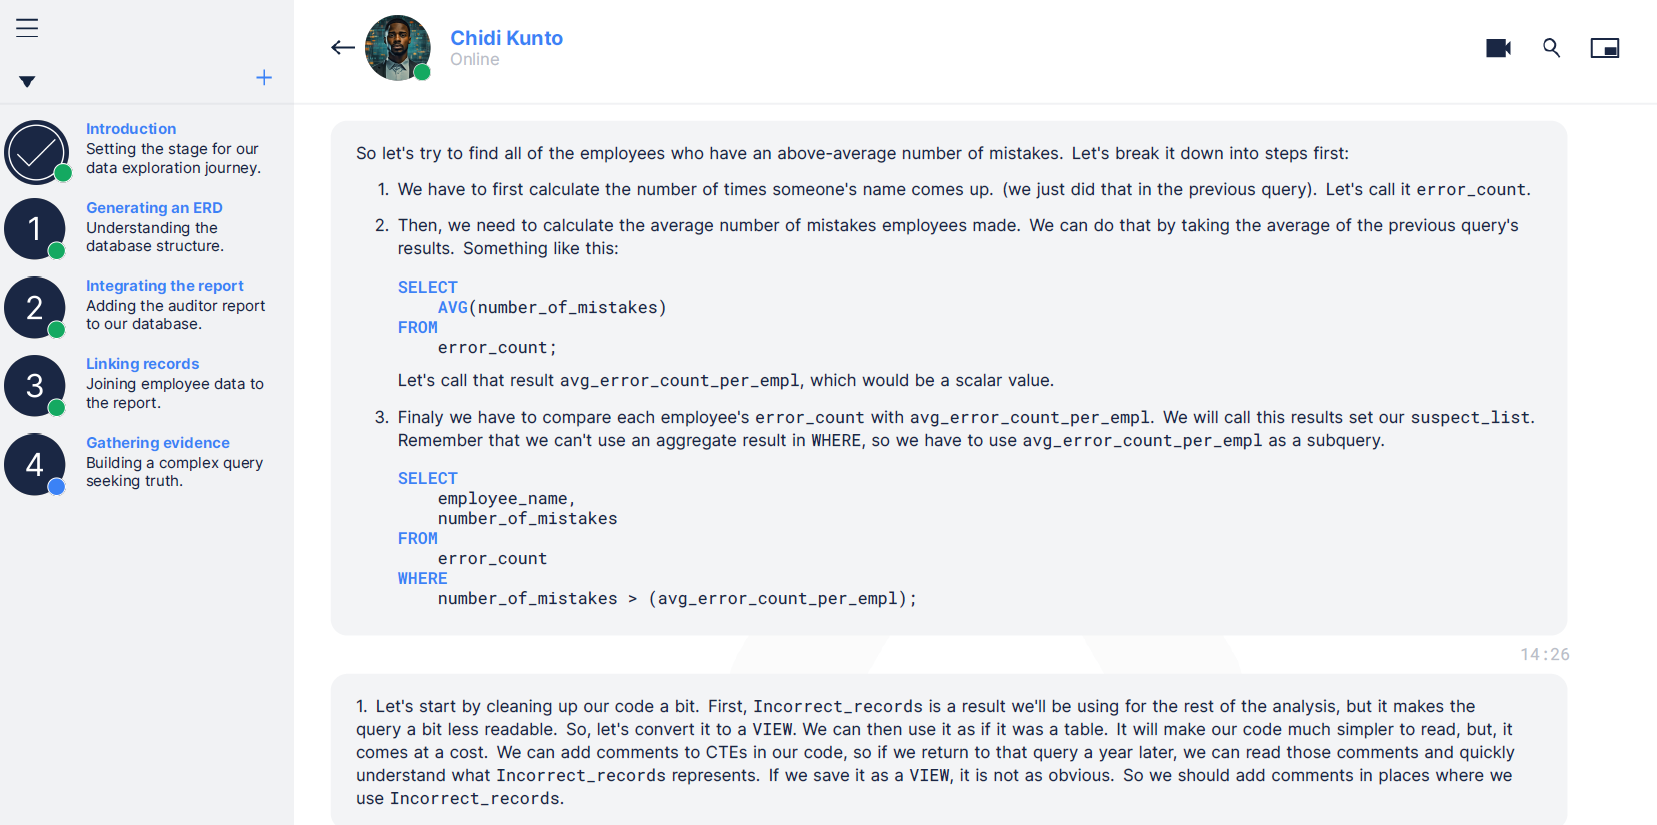

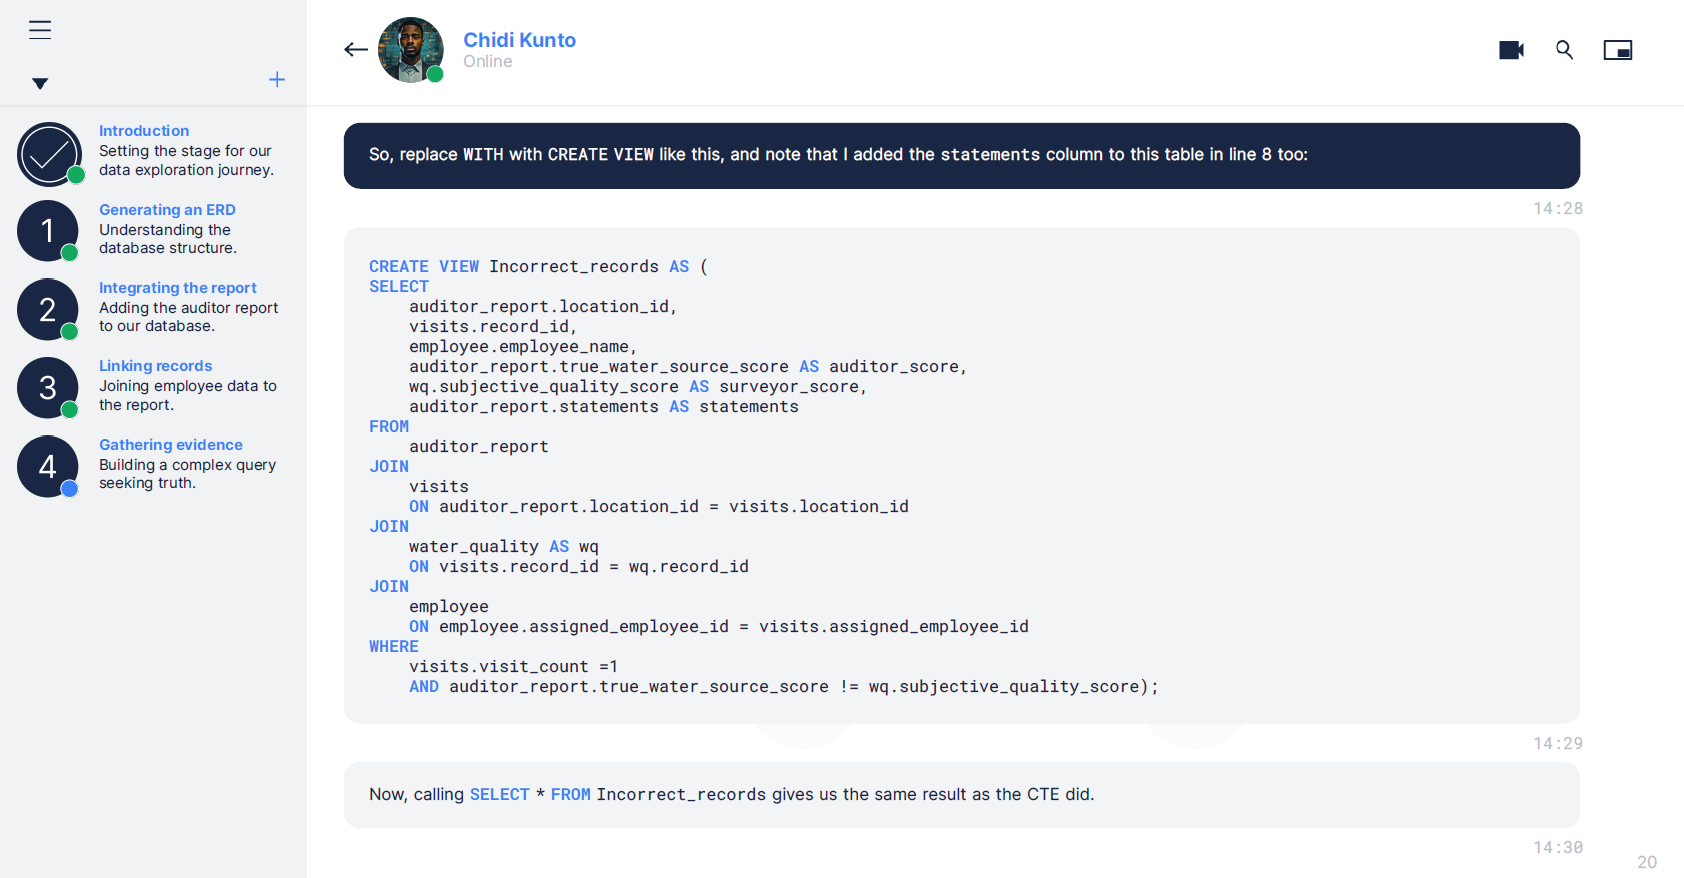

In [ ]:
%%sql
CREATE VIEW incorrect_records AS (
SELECT 
    a.location_id,
    v.record_id,
    e.employee_name employees,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN employee e ON v.assigned_employee_id = e.assigned_employee_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1);


In [ ]:
%%sql
SELECT * FROM incorrect_records LIMIT 5;

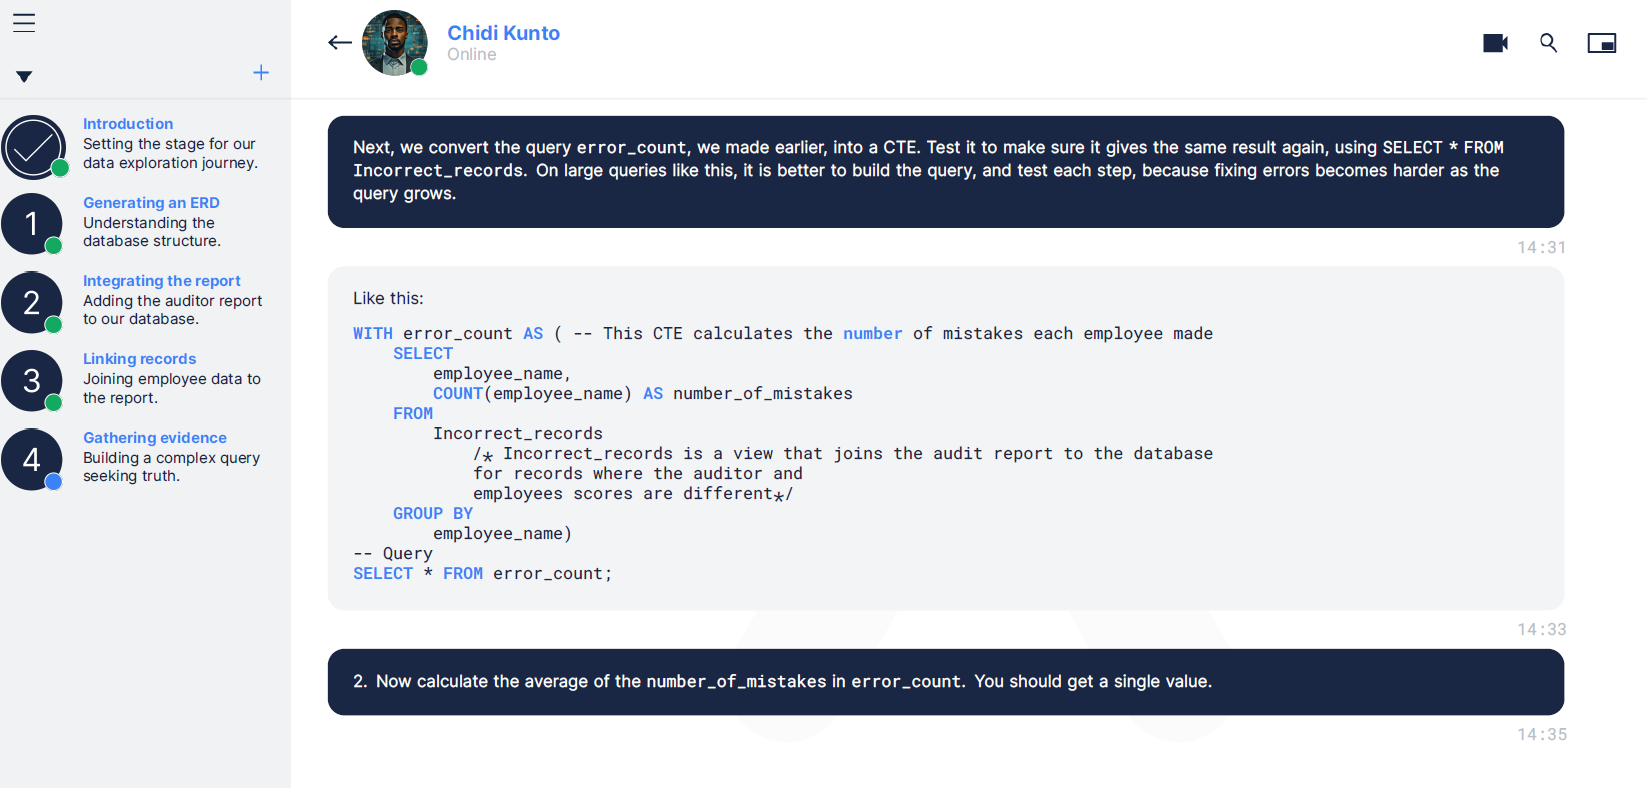

In [ ]:
%%sql
WITH error_count AS (
SELECT 
    employees,
    COUNT(*) AS number_of_mistakes 
FROM incorrect_records
GROUP BY employees
ORDER BY number_of_mistakes DESC)
SELECT * FROM error_count LIMIT 5;

In [ ]:
%%sql
WITH error_count AS (
SELECT 
    employees,
    COUNT(*) AS number_of_mistakes 
FROM incorrect_records
GROUP BY employees
ORDER BY number_of_mistakes DESC)
SELECT AVG(number_of_mistakes) FROM error_count;

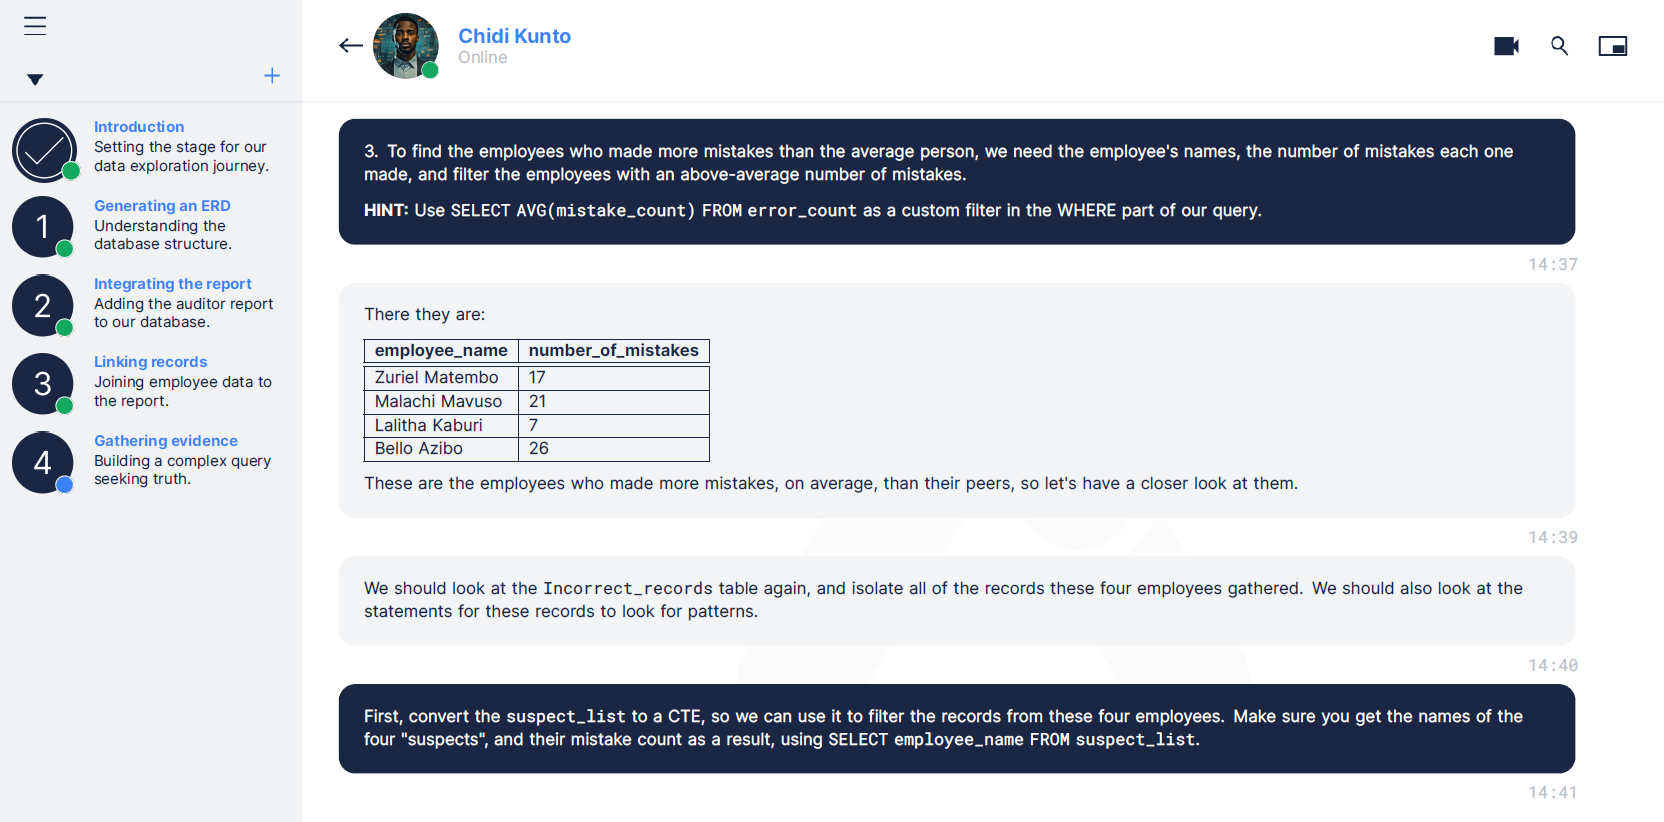

In [ ]:
%%sql
WITH error_count AS (
SELECT 
    employees,
    COUNT(*) AS number_of_mistakes 
FROM incorrect_records
GROUP BY employees
ORDER BY number_of_mistakes DESC)
SELECT 
    employees,
    number_of_mistakes
FROM error_count
WHERE number_of_mistakes > (SELECT AVG(number_of_mistakes) FROM error_count);

### This is the same output using a CTE instead of creating a view

In [ ]:
%%sql
WITH incorrect_records AS (
SELECT 
    a.location_id,
    v.record_id,
    e.employee_name employees,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN employee e ON v.assigned_employee_id = e.assigned_employee_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1)
,error_count AS (
SELECT 
    employees,
    COUNT(*) AS number_of_mistakes 
FROM incorrect_records
GROUP BY employees
ORDER BY number_of_mistakes DESC)
SELECT 
    employees,
    number_of_mistakes
FROM error_count
WHERE number_of_mistakes > (SELECT AVG(number_of_mistakes) FROM error_count);


In [ ]:
%%sql
WITH error_count AS (
SELECT 
    employees,
    COUNT(*) AS number_of_mistakes 
FROM incorrect_records
GROUP BY employees
ORDER BY number_of_mistakes DESC)
,Suspect_list AS (
SELECT 
    employees,
    number_of_mistakes
FROM error_count
WHERE number_of_mistakes > (SELECT AVG(number_of_mistakes) FROM error_count)
)
SELECT * FROM Suspect_list;

In [ ]:
%%sql
SELECT * FROM AUDITOR_REPORT LIMIT 5;

### Add statement to incorrect_records view

In [ ]:
%%sql
DROP VIEW IF EXISTS incorrect_records;

In [ ]:
%%sql
CREATE VIEW incorrect_records AS (
SELECT 
    a.location_id,
    v.record_id,
    e.employee_name employees,
    a.true_water_source_score AS auditor_score,
    w.subjective_quality_score surveyor_score,
    a.statements
FROM visits v
JOIN auditor_report a ON v.location_id = a.location_id
JOIN water_quality w ON v.record_id = w.record_id 
JOIN employee e ON v.assigned_employee_id = e.assigned_employee_id
WHERE w.subjective_quality_score != a.true_water_source_score AND v.visit_count = 1);


In [ ]:
%%sql
WITH error_count AS (
    SELECT 
        employees,
        COUNT(*) AS number_of_mistakes 
    FROM incorrect_records
    GROUP BY employees
),

suspect_list AS (
    SELECT 
        employees
    FROM error_count
    WHERE number_of_mistakes > (SELECT AVG(number_of_mistakes) FROM error_count)
)

SELECT 
    ir.employees,
    ir.location_id,
    ir.statements
FROM incorrect_records ir
WHERE ir.employees IN (SELECT employees FROM suspect_list)
ORDER BY ir.employees, ir.location_id LIMIT 5;


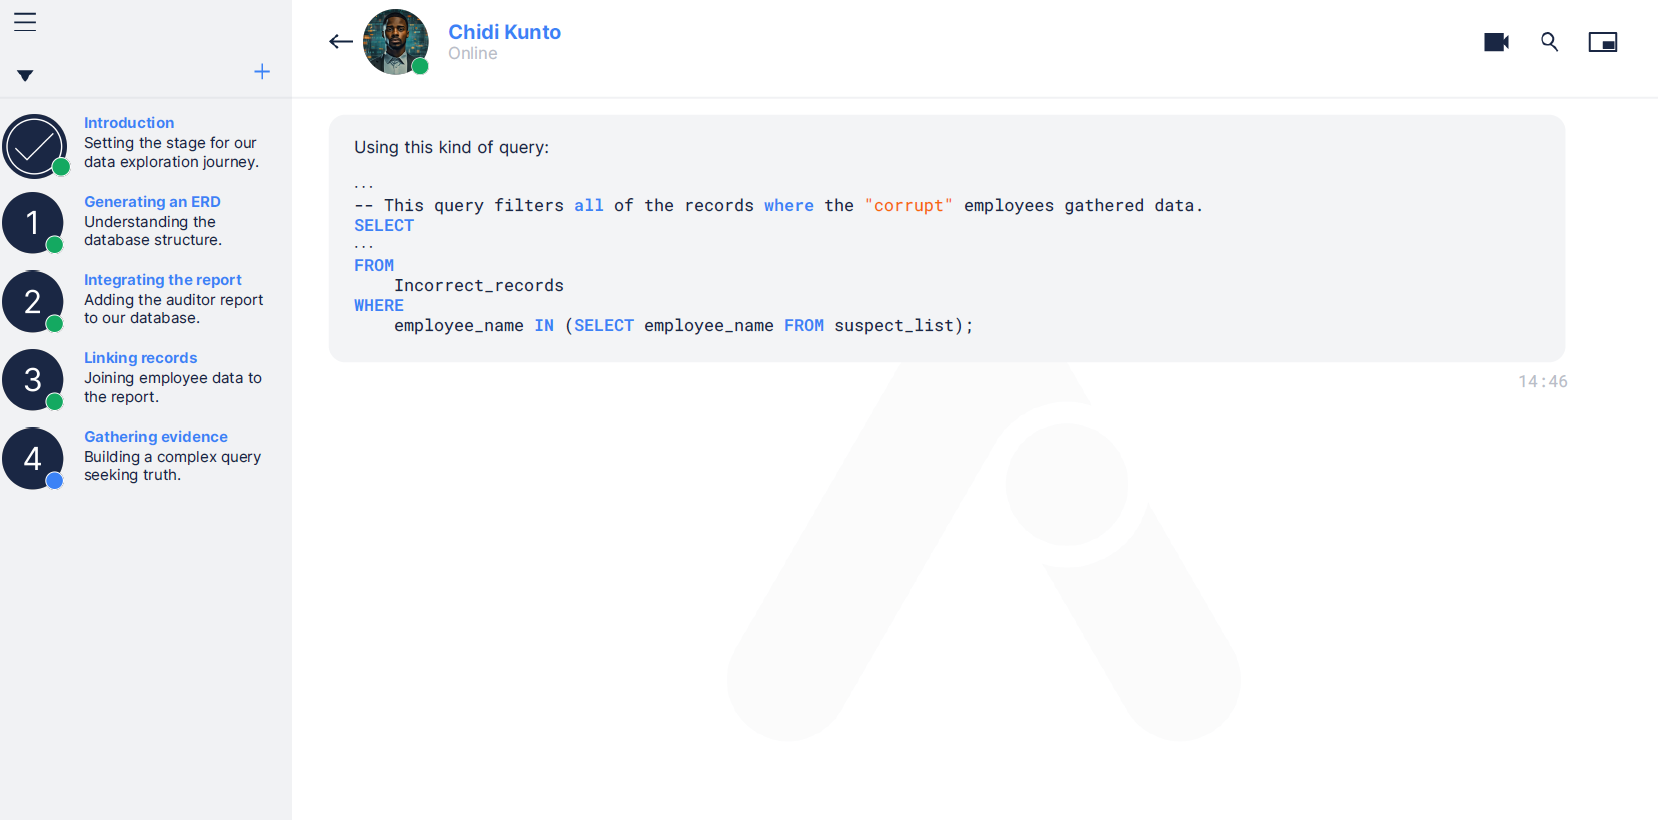

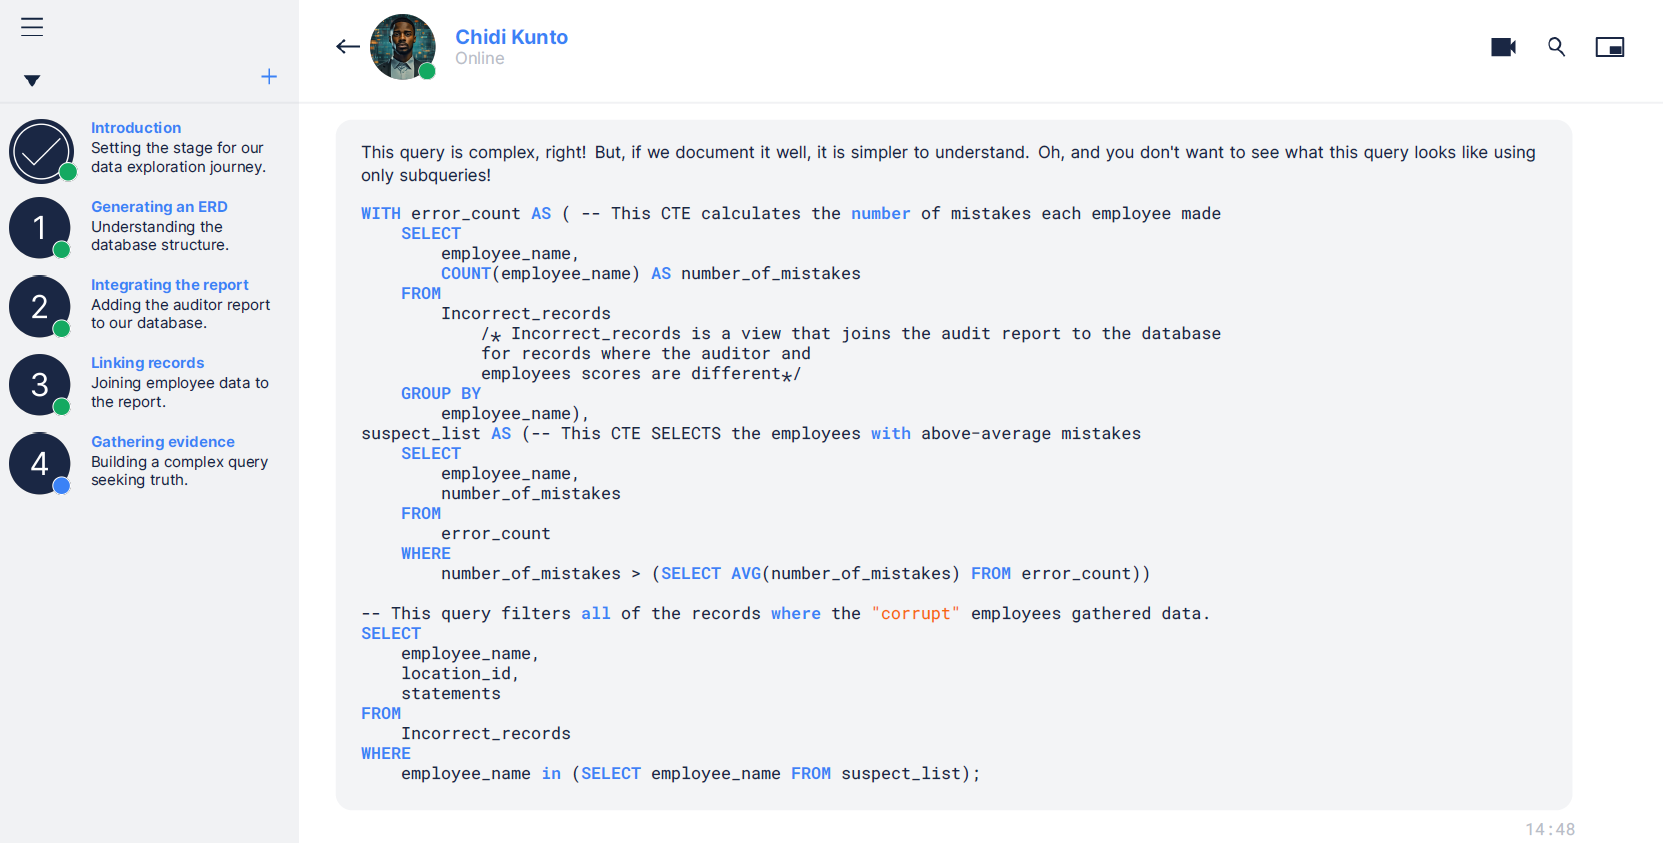

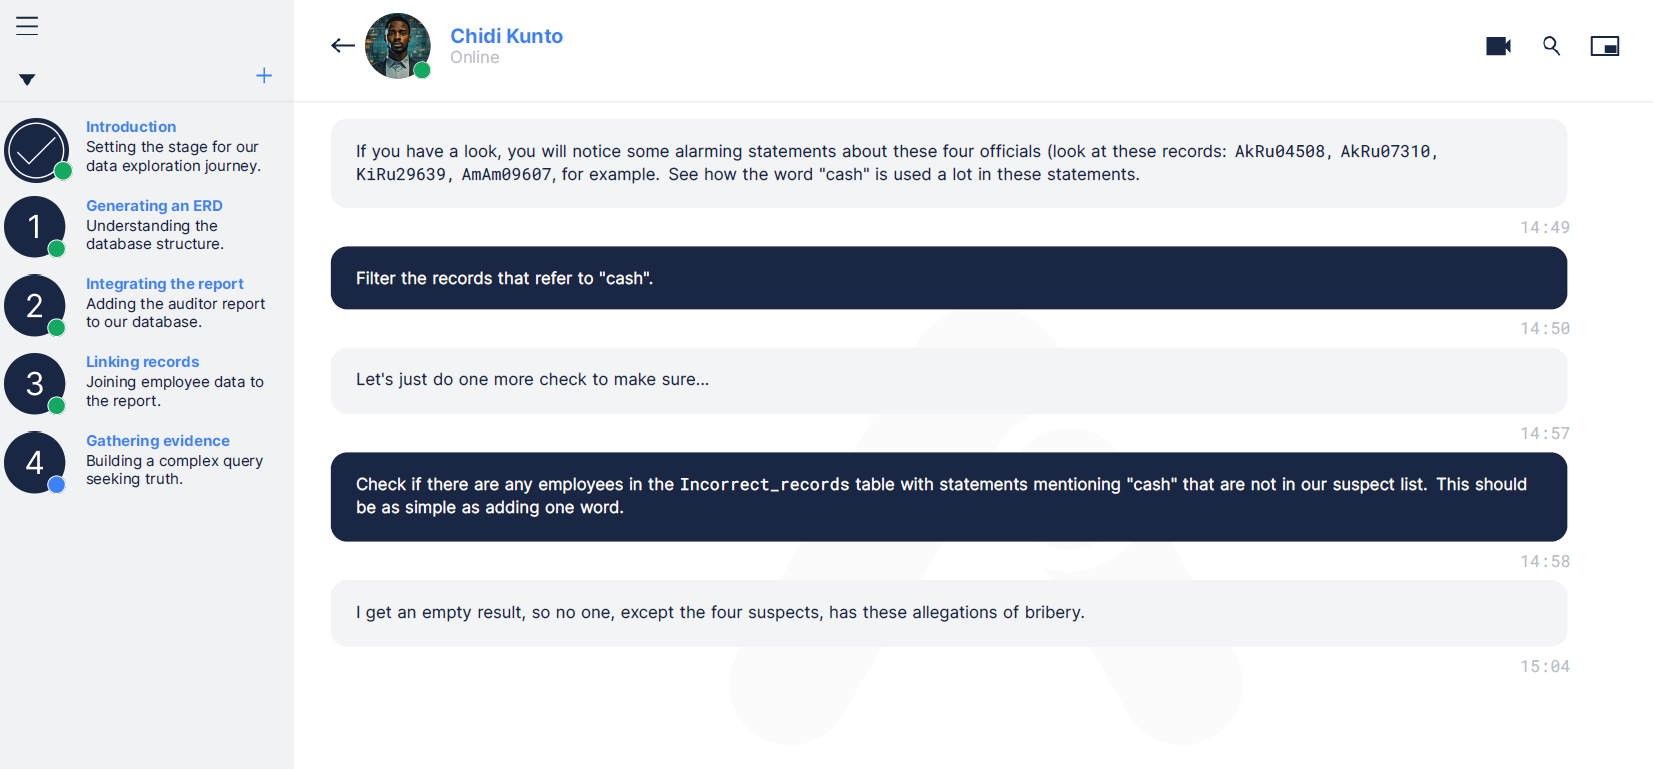

In [ ]:
%%sql
WITH error_count AS (
    SELECT 
        employees,
        COUNT(*) AS number_of_mistakes 
    FROM incorrect_records
    GROUP BY employees
),

suspect_list AS (
    SELECT 
        employees
    FROM error_count
    WHERE number_of_mistakes > (SELECT AVG(number_of_mistakes) FROM error_count)
)

SELECT 
    ir.employees,
    ir.location_id,
    ir.statements
FROM incorrect_records ir
WHERE ir.employees IN (SELECT employees FROM suspect_list) AND ir.statements LIKE '%cash%'
ORDER BY ir.employees, ir.location_id;


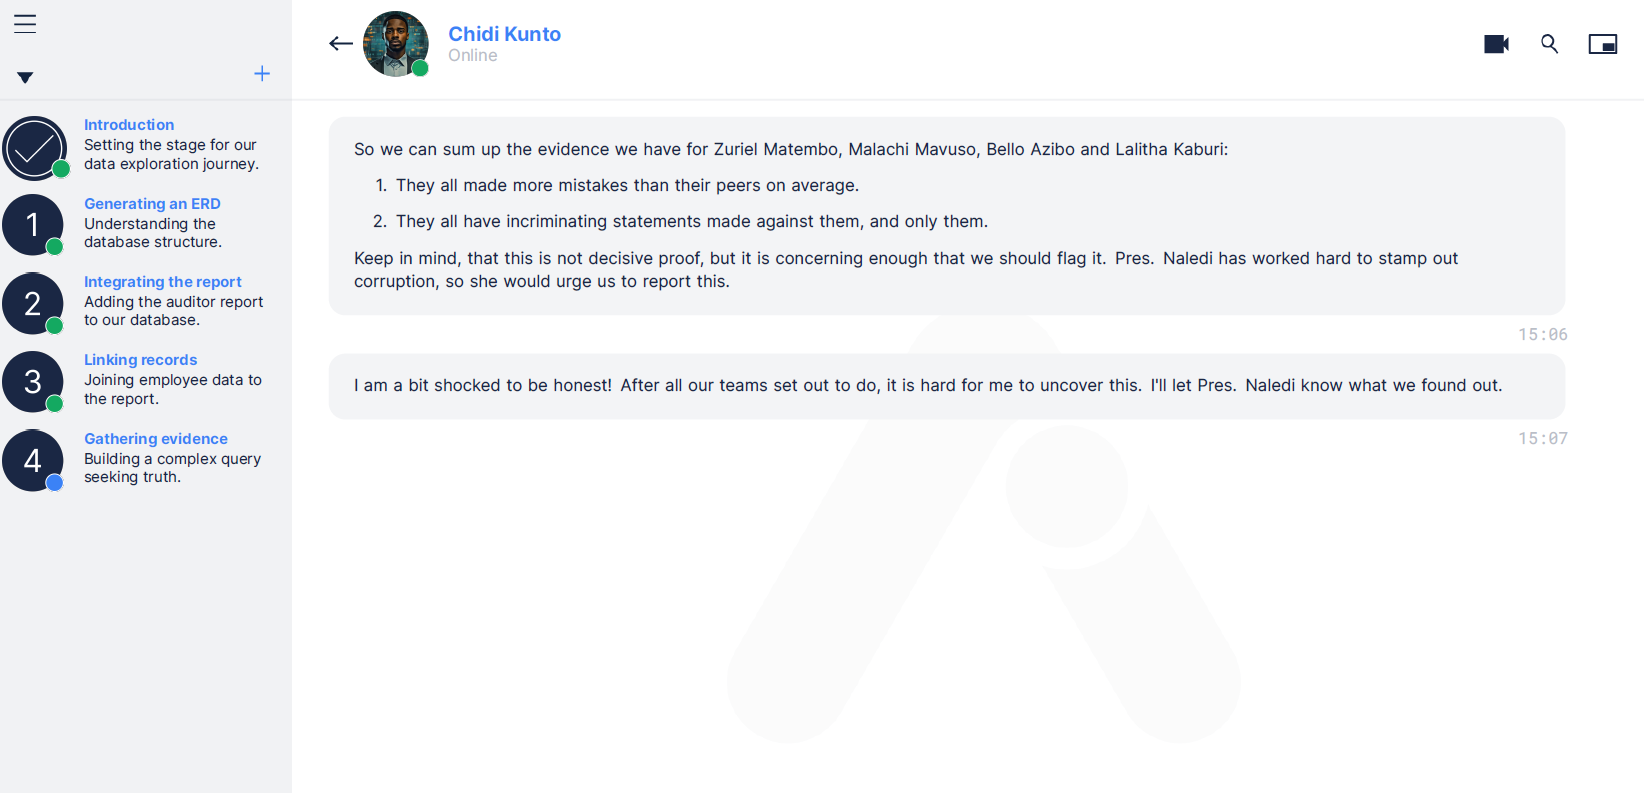

# END OF PART 3 